In [1]:
# STEP 1 — Install
!pip install -q scikit-learn
print("✅ Ready")

✅ Ready


In [2]:
# STEP 2 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = '/content/drive/MyDrive/ecg-multigraph-lab'
CKPT_DIR = f'{PROJECT_ROOT}/checkpoints'
PRED_DIR = f'{PROJECT_ROOT}/predictions'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)
print("✅ Drive mounted")                                   
# В конец STEP 2 добавить одну строку:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

Mounted at /content/drive
✅ Drive mounted


In [3]:
# STEP 3 — Load data
# ИСПРАВЛЕНО v1.1:
#   [🟡] Нормализация: глобальная mean/std → per-lead (axis=(0,2))
#        Старый вариант считал mean/std по всем отведениям вместе —
#        это допустимо для ResNet, но при per-lead GNN-архитектуре
#        разные отведения имеют разные амплитуды (aVR инвертирован,
#        V1 в 2-3x слабее V5), глобальная норм. искажает относительные
#        величины и мешает GNN сравнивать leads между собой.
# ─────────────────────────────────────────────────────────────────────────

import os
import numpy as np
from pathlib import Path
import torch


# ── Поиск файла ──────────────────────────────────────────────────────────
candidates = [
    '/content/drive/MyDrive/ecg-multigraph-lab/data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz',
    '/content/drive/MyDrive/ecg-multigraph-lab/ptbxl_sota_100hz_diagnostic_superclass.npz',
]
NPZ_PATH = None
for p in candidates:
    if os.path.exists(p):
        NPZ_PATH = p
        break

if NPZ_PATH is None:
    print('File not found in common locations, searching Drive...')
    drive_root = Path('/content/drive/MyDrive')
    matches = list(drive_root.rglob('ptbxl_sota_100hz_diagnostic_superclass.npz'))
    if not matches:
        raise FileNotFoundError('Could not find NPZ under /content/drive/MyDrive')
    NPZ_PATH = str(matches[0])
    print('Found candidates:')
    for m in matches:
        print(' -', m)
else:
    print('Found:', NPZ_PATH)


# ── Загрузка ─────────────────────────────────────────────────────────────
data = np.load(NPZ_PATH, allow_pickle=True)
print("NPZ keys:", list(data.files))

# Format 1: X_train / y_train
if all(k in data.files for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']):
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    print("✅ Format: X_train/y_train")

# Format 2: signals / labels / splits
elif all(k in data.files for k in ['signals', 'labels', 'splits']):
    splits = data['splits'].astype(str)
    X, y   = data['signals'], data['labels']
    X_train, y_train = X[splits == 'train'], y[splits == 'train']
    X_val,   y_val   = X[splits == 'val'],   y[splits == 'val']
    X_test,  y_test  = X[splits == 'test'],  y[splits == 'test']
    print("✅ Format: signals/labels/splits")

else:
    raise KeyError(f"Неизвестный формат NPZ. Ключи: {list(data.files)}")

# class names
if 'class_names' in data.files:
    class_names = [c.decode() if isinstance(c, bytes) else str(c)
                   for c in data['class_names']]
else:
    class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# dtype
X_train = X_train.astype(np.float32); y_train = y_train.astype(np.float32)
X_val   = X_val.astype(np.float32);   y_val   = y_val.astype(np.float32)
X_test  = X_test.astype(np.float32);  y_test  = y_test.astype(np.float32)

# Ожидаемая форма: [N, 12, 1000] или [N, 1000, 12] → приводим к [N, 12, 1000]
if X_train.ndim == 3 and X_train.shape[1] != 12 and X_train.shape[2] == 12:
    print(f"⚠️  Транспонируем {X_train.shape} → [N, 12, T]")
    X_train = X_train.transpose(0, 2, 1)
    X_val   = X_val.transpose(0, 2, 1)
    X_test  = X_test.transpose(0, 2, 1)

assert X_train.shape[1] == 12, f"Ожидали 12 отведений, получили {X_train.shape}"
N_LEADS = X_train.shape[1]   # 12
N_TIME  = X_train.shape[2]   # 1000


# ── Per-lead нормализация ─────────────────────────────────────────────────
# 🟡 ИСПРАВЛЕНО: считаем mean/std по оси (0=сэмплы, 2=время), отдельно
#    для каждого из 12 отведений → shape [1, 12, 1]
#
# Почему это важно для GNN-архитектуры:
#   - aVR инвертирован относительно остальных фронтальных отведений
#   - V1 имеет амплитуду ~0.1-0.3 mV, V5 — ~1.0-2.0 mV
#   - При глобальной нормализации GNN видит систематически смещённые
#     значения по отведениям и не может корректно сравнивать leads
#   - Per-lead норм. выравнивает амплитудный масштаб, сохраняя форму

print(f"\nФорма данных: {X_train.shape}  [N, leads, time]")
print(f"\nДо нормализации (среднее по отведениям):")
lead_means_before = X_train.mean(axis=(0, 2))
lead_stds_before  = X_train.std(axis=(0, 2))
for i, name in enumerate(LEAD_NAMES):
    print(f"  {name:4s}: mean={lead_means_before[i]:+.4f}, std={lead_stds_before[i]:.4f}")

# Статистики ТОЛЬКО по train (без val/test — нет data leakage)
lead_mean = X_train.mean(axis=(0, 2), keepdims=True)   # [1, 12, 1]
lead_std  = X_train.std(axis=(0, 2),  keepdims=True)   # [1, 12, 1]

# Проверяем что нет «мёртвых» отведений
if (lead_std < 1e-6).any():
    bad = [LEAD_NAMES[i] for i in np.where((lead_std < 1e-6).flatten())[0]]
    raise ValueError(f"Нулевой std в отведениях: {bad}. Проверь данные.")

X_train = (X_train - lead_mean) / lead_std
X_val   = (X_val   - lead_mean) / lead_std   # используем train-статистику
X_test  = (X_test  - lead_mean) / lead_std   # используем train-статистику

print(f"\nПосле нормализации (среднее по отведениям):")
lead_means_after = X_train.mean(axis=(0, 2))
lead_stds_after  = X_train.std(axis=(0, 2))
for i, name in enumerate(LEAD_NAMES):
    print(f"  {name:4s}: mean={lead_means_after[i]:+.5f}, std={lead_stds_after[i]:.4f}")


# ── Итоговые размеры ──────────────────────────────────────────────────────
print(f"\nTrain : {X_train.shape}  labels: {y_train.shape}")
print(f"Val   : {X_val.shape}   labels: {y_val.shape}")
print(f"Test  : {X_test.shape}  labels: {y_test.shape}")
print(f"Classes: {class_names}")


# ── pos_weight для BCEWithLogitsLoss ──────────────────────────────────────
# Сглаживающий exp=0.6 снижает агрессивность весов для очень редких классов
pos_counts    = y_train.sum(axis=0)                          # [5]
neg_counts    = len(y_train) - pos_counts                    # [5]
alpha         = 0.5
pos_weight_np = ((neg_counts / (pos_counts + 1e-6)) ** alpha).astype(np.float32)

print(f"\npos_weight (alpha={alpha}):")
for i, name in enumerate(class_names):
    print(f"  {name:4s}: neg/pos={neg_counts[i]:.0f}/{pos_counts[i]:.0f} "
          f"→ weight={pos_weight_np[i]:.3f}")

pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32)


# ── Сохраняем статистику нормализации (нужна при инференсе) ───────────────
norm_stats = {
    'lead_mean' : lead_mean,   # [1, 12, 1] np.float32
    'lead_std'  : lead_std,    # [1, 12, 1] np.float32
}
print("\n✅ STEP 3 OK — per-lead нормализация, статистика сохранена в norm_stats")
print("   [🟡] lead_mean/lead_std shape:", lead_mean.shape, lead_std.shape)
print("   [🟢] Утечки нет: val/test нормированы по train-статистике")
print("   [🟢] norm_stats доступен для инференса без повторного расчёта")

File not found in common locations, searching Drive...
Found candidates:
 - /content/drive/MyDrive/ecg-diploma/data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz
NPZ keys: ['signals', 'labels', 'splits', 'ecg_ids', 'class_names', 'sampling_rate']
✅ Format: signals/labels/splits

Форма данных: (17418, 12, 1000)  [N, leads, time]

До нормализации (среднее по отведениям):
  I   : mean=+0.0000, std=0.9999
  II  : mean=-0.0000, std=0.9999
  III : mean=-0.0000, std=0.9995
  aVR : mean=+0.0000, std=0.9999
  aVL : mean=-0.0000, std=0.9997
  aVF : mean=-0.0000, std=0.9997
  V1  : mean=+0.0000, std=0.9998
  V2  : mean=+0.0000, std=0.9999
  V3  : mean=-0.0000, std=0.9999
  V4  : mean=+0.0000, std=0.9999
  V5  : mean=-0.0000, std=0.9999
  V6  : mean=+0.0000, std=0.9999

После нормализации (среднее по отведениям):
  I   : mean=+0.00000, std=0.9999
  II  : mean=-0.00000, std=0.9999
  III : mean=-0.00000, std=1.0000
  aVR : mean=-0.00000, std=1.0000
  aVL : mean=-0.00000, std=1.0001
  aVF :

In [4]:
# STEP 4 — DataLoaders (Experiment A: HYP-targeted sampler)
# ИСПРАВЛЕНО v1.2:
#   [🔴→✅] BATCH_SIZE: 128 → 32  (OOM fix: LeadWise делает B×12 примеров)
#   [🟢]   ACCUM_STEPS=4 → эффективный батч = 32×4 = 128 (без потери качества)
#   [🟡]   HYP_W авто из данных (strength=0.2)
# ─────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ── Ключевые константы ────────────────────────────────────────────────────
BATCH_SIZE       = 32    # 🔴 ИСПРАВЛЕНО: было 128 → OOM (LeadWise: B×12 в ResNet)
ACCUM_STEPS      = 4     # 🟢 gradient accumulation → эффективный батч = 128
HYP_IDX          = 4     # [NORM=0, MI=1, STTC=2, CD=3, HYP=4]
SAMPLER_STRENGTH = 0.2   # мягкая компенсация (см. аудит ниже)

# Память-калькулятор для справки:
# LeadWise forward: [B, 12, 1000] → reshape → [B*12, 1, 1000]
# При B=128: 128×12=1536 примеров × ~3MB каждый ≈ 4.6GB только activations
# При B=32:  32×12=384  примеров × ~3MB каждый ≈ 1.15GB ✅
print(f"⚙️  BATCH_SIZE={BATCH_SIZE} | ACCUM_STEPS={ACCUM_STEPS} "
      f"| effective_batch={BATCH_SIZE*ACCUM_STEPS}")


def compute_sample_weights(y: np.ndarray,
                           hyp_idx: int = HYP_IDX,
                           sampler_strength: float = 0.5) -> torch.Tensor:
    n_total   = len(y)
    pos_count = y[:, hyp_idx].sum()
    neg_count = n_total - pos_count

    if pos_count == 0:
        raise ValueError(f"Класс HYP_IDX={hyp_idx} не встречается в выборке!")

    full_hyp_w = neg_count / pos_count
    hyp_w      = full_hyp_w ** sampler_strength

    norm_count  = ((y[:, 0] > 0.5) & (y[:, 1:].sum(axis=1) < 0.5)).sum()
    norm_full_w = n_total / (norm_count + 1e-6)
    norm_w      = (1.0 / norm_full_w) ** sampler_strength

    weights = np.ones(n_total, dtype=np.float32)
    for i, label in enumerate(y):
        if label[hyp_idx] > 0.5:
            weights[i] = hyp_w
        elif label[0] > 0.5 and label[1:].sum() < 0.5:
            weights[i] = max(norm_w, 0.5)

    return torch.tensor(weights, dtype=torch.float32)


def print_effective_weights(pos_weight_tensor, y, hyp_idx=HYP_IDX,
                             sampler_strength=SAMPLER_STRENGTH):
    sample_w      = compute_sample_weights(y, hyp_idx, sampler_strength)
    pos_count     = y[:, hyp_idx].sum()
    neg_count     = len(y) - pos_count
    hyp_sampler_w = sample_w[y[:, hyp_idx] > 0.5].mean().item()
    hyp_loss_w    = pos_weight_tensor[hyp_idx].item()

    print(f"\n📊 Аудит эффективных весов HYP:")
    print(f"   Частота HYP      : {pos_count:.0f}/{len(y)} = {pos_count/len(y)*100:.1f}%")
    print(f"   neg/pos (raw)    : {neg_count/pos_count:.2f}x")
    print(f"   sampler_strength : {sampler_strength}")
    print(f"   Sampler вес HYP  : {hyp_sampler_w:.2f}x")
    print(f"   pos_weight HYP   : {hyp_loss_w:.2f}x")
    print(f"   ─────────────────────────────────────")
    eff    = hyp_sampler_w * hyp_loss_w
    status = "✅ OK" if eff <= 4.0 else ("⚠️  ВЫСОКИЙ" if eff <= 6.0 else "🔴 СЛИШКОМ МНОГО")
    print(f"   Эффективный вес  : {eff:.2f}x  {status}")
    print(f"   (безопасная зона: ≤ 4.0x)")


# ── Dataset ───────────────────────────────────────────────────────────────
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_dataset = ECGDataset(X_train, y_train)
val_dataset   = ECGDataset(X_val,   y_val)
test_dataset  = ECGDataset(X_test,  y_test)


# ── DataLoaders ───────────────────────────────────────────────────────────
def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                weighted=False, y=None,
                sampler_strength=SAMPLER_STRENGTH):
    sampler = None
    if weighted:
        assert y is not None
        weights = compute_sample_weights(y, HYP_IDX, sampler_strength)
        sampler = WeightedRandomSampler(
            weights,
            num_samples = len(weights),
            replacement = True,
        )
        shuffle = False

    return DataLoader(
        dataset,
        batch_size         = batch_size,
        shuffle            = shuffle,
        sampler            = sampler,
        num_workers        = 2,
        pin_memory         = True,
        persistent_workers = True,
        prefetch_factor    = 2,
    )


train_loader = make_loader(train_dataset, weighted=True, y=y_train)
val_loader   = make_loader(val_dataset,   shuffle=False)
test_loader  = make_loader(test_dataset,  shuffle=False)


# ── Аудит ────────────────────────────────────────────────────────────────
print_effective_weights(pos_weight, y_train,
                        hyp_idx=HYP_IDX,
                        sampler_strength=SAMPLER_STRENGTH)

X_b, y_b = next(iter(train_loader))
hyp_in_batch  = y_b[:, HYP_IDX].sum().item()
norm_in_batch = y_b[:, 0].sum().item()

print(f"\n✅ Datasets  — Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"✅ Loaders   — Train: {len(train_loader)} батчей | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"📊 Батч-чек  — HYP: {hyp_in_batch:.0f}/{len(y_b)} ({hyp_in_batch/len(y_b)*100:.1f}%) | "
      f"NORM: {norm_in_batch:.0f}/{len(y_b)} ({norm_in_batch/len(y_b)*100:.1f}%)")
print(f"\n✅ STEP 4 OK — DataLoaders v1.2")
print(f"   [🔴→✅] BATCH_SIZE=32 (OOM fix, effective=128 через ACCUM_STEPS=4)")
print(f"   [🟡]   HYP_W авто из данных (strength={SAMPLER_STRENGTH})")
print(f"   [🟢]   ACCUM_STEPS={ACCUM_STEPS} — объявлен здесь, используется в STEP 9")

⚙️  BATCH_SIZE=32 | ACCUM_STEPS=4 | effective_batch=128

📊 Аудит эффективных весов HYP:
   Частота HYP      : 2119/17418 = 12.2%
   neg/pos (raw)    : 7.22x
   sampler_strength : 0.2
   Sampler вес HYP  : 1.48x
   pos_weight HYP   : 2.69x
   ─────────────────────────────────────
   Эффективный вес  : 3.99x  ✅ OK
   (безопасная зона: ≤ 4.0x)

✅ Datasets  — Train: 17,418 | Val: 2,183 | Test: 2,198
✅ Loaders   — Train: 545 батчей | Val: 69 | Test: 69
📊 Батч-чек  — HYP: 3/32 (9.4%) | NORM: 9/32 (28.1%)

✅ STEP 4 OK — DataLoaders v1.2
   [🔴→✅] BATCH_SIZE=32 (OOM fix, effective=128 через ACCUM_STEPS=4)
   [🟡]   HYP_W авто из данных (strength=0.2)
   [🟢]   ACCUM_STEPS=4 — объявлен здесь, используется в STEP 9


In [5]:
# STEP 5 — ResNet1dWang (baseline) + LeadWiseResNet1d (GNN encoder) + перенос весов

import os
import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────────────────────────────────────
# БЛОК A: Общие примитивы
# ─────────────────────────────────────────────────────────────────────────

class AdaptiveConcatPool1d(nn.Module):
    def __init__(self):
        super().__init__()
        self.ap = nn.AdaptiveAvgPool1d(1)
        self.mp = nn.AdaptiveMaxPool1d(1)
    def forward(self, x):
        return torch.cat([self.mp(x), self.ap(x)], dim=1)

def create_head1d(nf, nc, ps=0.5):
    return nn.Sequential(
        AdaptiveConcatPool1d(),
        nn.Flatten(),
        nn.BatchNorm1d(2 * nf),
        nn.Dropout(ps / 2),
        nn.Linear(2 * nf, 512, bias=False),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(ps),
        nn.Linear(512, nc),
    )

def conv1d_pad(in_planes, out_planes, stride=1, kernel_size=3):
    return nn.Conv1d(
        in_planes, out_planes,
        kernel_size=kernel_size,
        stride=stride,
        padding=(kernel_size - 1) // 2,
        bias=False,
    )

class BasicBlock1d(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1,
                 kernel_size=[5, 3], downsample=None):
        super().__init__()
        if isinstance(kernel_size, int):
            kernel_size = [kernel_size, kernel_size // 2 + 1]
        self.conv1      = conv1d_pad(inplanes, planes, stride=stride, kernel_size=kernel_size[0])
        self.bn1        = nn.BatchNorm1d(planes)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = conv1d_pad(planes,   planes, kernel_size=kernel_size[1])
        self.bn2        = nn.BatchNorm1d(planes)
        self.downsample = downsample
        self.stride     = stride

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        return self.relu(out)

def _make_layer(in_planes, planes, blocks, stride, kernel_size):
    downsample = None
    if stride != 1 or in_planes != planes * BasicBlock1d.expansion:
        downsample = nn.Sequential(
            nn.Conv1d(in_planes, planes * BasicBlock1d.expansion,
                      kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm1d(planes * BasicBlock1d.expansion),
        )
    layers = [BasicBlock1d(in_planes, planes, stride, kernel_size, downsample)]
    for _ in range(1, blocks):
        layers.append(BasicBlock1d(planes, planes, kernel_size=kernel_size))
    return nn.Sequential(*layers)


# ─────────────────────────────────────────────────────────────────────────
# БЛОК B: ResNet1dWang — оригинал (нужен для загрузки весов baseline)
# ─────────────────────────────────────────────────────────────────────────

class ResNet1dWang(nn.Module):
    def __init__(self, num_classes=5, input_channels=12, ps_head=0.5):
        super().__init__()
        inplanes    = 128
        kernel_size = [5, 3]
        self.stem   = nn.Sequential(
            conv1d_pad(input_channels, inplanes, stride=1, kernel_size=7),
            nn.BatchNorm1d(inplanes),
            nn.ReLU(inplace=True),
        )
        self.layer1 = _make_layer(inplanes, inplanes, blocks=1, stride=1, kernel_size=kernel_size)
        self.layer2 = _make_layer(inplanes, inplanes, blocks=1, stride=2, kernel_size=kernel_size)
        self.layer3 = _make_layer(inplanes, inplanes, blocks=1, stride=2, kernel_size=kernel_size)
        self.head   = create_head1d(inplanes, nc=num_classes, ps=ps_head)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.head(x)


# ─────────────────────────────────────────────────────────────────────────
# БЛОК C: LeadWiseResNet1d — энкодер для GNN
# ─────────────────────────────────────────────────────────────────────────

class LeadWiseResNet1d(nn.Module):
    """
    Lead-wise версия ResNet1dWang.
    Каждый из 12 leads обрабатывается ОДНОЙ сетью (weight sharing).
    Вход:  [B, 12, 1000]
    Выход: [B, 12, embed_dim]  ← узлы графа GNN
    """
    def __init__(self, embed_dim=128, dropout=0.1):
        super().__init__()
        inplanes    = 128
        kernel_size = [5, 3]

        self.stem = nn.Sequential(
            conv1d_pad(1, inplanes, stride=1, kernel_size=7),  # 1 канал вместо 12
            nn.BatchNorm1d(inplanes),
            nn.ReLU(inplace=True),
        )
        self.layer1 = _make_layer(inplanes, inplanes, blocks=1, stride=1, kernel_size=kernel_size)
        self.layer2 = _make_layer(inplanes, inplanes, blocks=1, stride=2, kernel_size=kernel_size)
        self.layer3 = _make_layer(inplanes, inplanes, blocks=1, stride=2, kernel_size=kernel_size)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(inplanes),
            nn.Dropout(dropout),
            nn.Linear(inplanes, embed_dim, bias=False),
        )
        self.embed_dim = embed_dim

    def forward(self, x):
        B, L, T = x.shape
        x = x.reshape(B * L, 1, T)   # [B*12, 1, 1000]
        h = self.stem(x)              # [B*12, 128, 1000]
        h = self.layer1(h)            # [B*12, 128, 1000]
        h = self.layer2(h)            # [B*12, 128,  500]
        h = self.layer3(h)            # [B*12, 128,  250]
        h = self.pool(h)              # [B*12, 128,    1]
        h = self.proj(h)              # [B*12, embed_dim]
        return h.reshape(B, L, -1)   # [B, 12, embed_dim]


# ─────────────────────────────────────────────────────────────────────────
# БЛОК D: Перенос весов baseline → LeadWiseResNet1d
# ─────────────────────────────────────────────────────────────────────────

def load_leadwise_from_baseline(leadwise_model, ckpt_path, device='cpu'):
    """
    Переносит веса из обученного ResNet1dWang в LeadWiseResNet1d.
    
    Переносится : layer1/2/3 (все Conv+BN), stem BN
    stem.0.weight: 12-канальный → 1-канальный через mean по каналам
                   (эвристика, лучше чем random init, но не идеал)
    Пропускается : head (убрана)
    """
    baseline_state = torch.load(ckpt_path, map_location=device)
    leadwise_state  = leadwise_model.state_dict()

    transferred, skipped_shape, skipped_absent, adapted = 0, 0, 0, 0

    for k, v in baseline_state.items():
        # head — не нужен
        if k.startswith('head'):
            skipped_absent += 1
            continue

        # ── Специальный случай: stem.0.weight [128,12,7] → [128,1,7]
        if k == 'stem.0.weight':
            if k in leadwise_state and leadwise_state[k].shape == (128, 1, 7):
                leadwise_state[k] = v.mean(dim=1, keepdim=True)
                adapted += 1
                print(f"   ⚡ stem.0.weight: усреднён [128,12,7]→[128,1,7] (warm init)")
            else:
                skipped_shape += 1
            continue

        # Обычный перенос
        if k in leadwise_state:
            if leadwise_state[k].shape == v.shape:
                leadwise_state[k] = v
                transferred += 1
            else:
                skipped_shape += 1
        else:
            skipped_absent += 1

    leadwise_model.load_state_dict(leadwise_state, strict=False)
    print(f"✅ Перенесено : {transferred} тензоров (layer1/2/3 + stem BN)")
    print(f"   Адаптировано: {adapted} (stem.0.weight warm init)")
    print(f"   Пропущено  : {skipped_absent} (head — ожидаемо)")
    if skipped_shape > 0:
        print(f"   ⚠️ Несовпадение формы: {skipped_shape} тензоров")
    return leadwise_model


# ─────────────────────────────────────────────────────────────────────────
# БЛОК E: Конфиг путей + проверка
# ─────────────────────────────────────────────────────────────────────────

from pathlib import Path

EMBED_DIM  = 128
DRIVE_ROOT = Path('/content/drive/MyDrive/ecg-multigraph-lab')

# Автопоиск чекпоинта baseline
_ckpt_candidates = [
    DRIVE_ROOT / 'checkpoints' / 'resnet1d_wang_baseline.pth',  # ← правильное имя
    DRIVE_ROOT / 'checkpoints' / 'best_resnet1d_wang.pth',
    DRIVE_ROOT / 'checkpoints' / 'best.pth',
    DRIVE_ROOT / 'best.pth',
]
CKPT_PATH = None
for _c in _ckpt_candidates:
    if _c.exists():
        CKPT_PATH = str(_c)
        break

if CKPT_PATH is None:
    # Широкий поиск по всему Drive
    _found = list(DRIVE_ROOT.rglob('best*.pth'))
    if _found:
        CKPT_PATH = str(_found[0])
        print(f"ℹ️  Чекпоинт найден поиском: {CKPT_PATH}")
    else:
        print("⚠️  Чекпоинт baseline не найден. Запусти 01_baseline.ipynb → STEP 8.")
else:
    print(f"✅ Чекпоинт baseline: {CKPT_PATH}")

# ── Тест 1: ResNet1dWang (оригинал не сломан) ────────────────────────────
_baseline = ResNet1dWang(num_classes=5, input_channels=12)
_x        = torch.randn(4, 12, 1000)
_out      = _baseline(_x)
_p        = sum(p.numel() for p in _baseline.parameters())
print(f"\nResNet1dWang     → output: {_out.shape}  params: {_p:,}")
assert _out.shape == (4, 5), "❌ ResNet1dWang shape mismatch!"
print("✅ ResNet1dWang OK")

# ── Тест 2: LeadWiseResNet1d ─────────────────────────────────────────────
_encoder = LeadWiseResNet1d(embed_dim=EMBED_DIM)
_out_lw  = _encoder(_x)
_p_lw    = sum(p.numel() for p in _encoder.parameters())
print(f"\nLeadWiseResNet1d → output: {_out_lw.shape}  params: {_p_lw:,}")
assert _out_lw.shape == (4, 12, EMBED_DIM), "❌ LeadWise shape mismatch!"
print("✅ LeadWiseResNet1d OK")

# ── Тест 3: Перенос весов ────────────────────────────────────────────────
if CKPT_PATH:
    print(f"\nПеренос весов из: {CKPT_PATH}")
    _encoder = load_leadwise_from_baseline(_encoder, CKPT_PATH, device='cpu')
else:
    print("\n⚠️  Перенос весов пропущен — чекпоинт не найден (random init).")

print(f"\n{'='*55}")
print(f"✅ STEP 5 OK — LeadWiseResNet1d готов к GNN-head")
print(f"   Узлы графа : 12 leads × {EMBED_DIM} dims")
print(f"   CKPT_PATH  : {CKPT_PATH}")
print(f"   EMBED_DIM  : {EMBED_DIM}")
print(f"{'='*55}")

✅ Чекпоинт baseline: /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/resnet1d_wang_baseline.pth

ResNet1dWang     → output: torch.Size([4, 5])  params: 574,213
✅ ResNet1dWang OK

LeadWiseResNet1d → output: torch.Size([4, 12, 128])  params: 445,824
✅ LeadWiseResNet1d OK

Перенос весов из: /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/resnet1d_wang_baseline.pth
   ⚡ stem.0.weight: усреднён [128,12,7]→[128,1,7] (warm init)
✅ Перенесено : 53 тензоров (layer1/2/3 + stem BN)
   Адаптировано: 1 (stem.0.weight warm init)
   Пропущено  : 13 (head — ожидаемо)

✅ STEP 5 OK — LeadWiseResNet1d готов к GNN-head
   Узлы графа : 12 leads × 128 dims
   CKPT_PATH  : /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/resnet1d_wang_baseline.pth
   EMBED_DIM  : 128


In [6]:
# STEP 6 — Metrics
# ИСПРАВЛЕНО v1.1:
#   [🟢9]  Убран дублированный @torch.no_grad() декоратор
#   [🟢10] compute_J синхронизирован со STEP 9:
#          J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC (без двойного счёта HYP)
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score


CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
HYP_IDX     = 4


def fmax_score(y_true: np.ndarray, y_prob: np.ndarray,
               n_thresh: int = 201) -> tuple:
    """
    Macro-F1 максимизированный по порогу — стандарт PTB-XL бенчмарка.
    n_thresh=201 → шаг 0.005, точнее находит пик F1.
    Возвращает (best_f1, best_threshold).
    """
    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.0, 1.0, n_thresh):
        f1 = f1_score(y_true, (y_prob >= t).astype(int),
                      average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_f1, best_t


def compute_J(probs: np.ndarray, labels: np.ndarray) -> tuple:
    """
    Composite early-stop score (синхронизирован со STEP 9).

    J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC

    Веса в сумме = 1.0, HYP не считается дважды.
    Возвращает (J, macro_auprc, hyp_auprc).
    """
    macro_auprc = average_precision_score(labels, probs, average='macro')
    hyp_auprc   = average_precision_score(labels[:, HYP_IDX], probs[:, HYP_IDX])
    J           = 0.6 * macro_auprc + 0.4 * hyp_auprc
    return J, macro_auprc, hyp_auprc


@torch.no_grad()   # 🟢9: убран дублированный декоратор
def evaluate(model, loader, device):
    """
    Полная оценка модели на переданном DataLoader.
    Возвращает dict со всеми метриками.
    """
    model.eval()
    all_probs, all_labels = [], []

    for X, y in loader:
        logits, _ = model(X.to(device))    # распаковываем (logits, attn_dict)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.numpy())

    probs  = np.concatenate(all_probs)     # [N, 5]
    labels = np.concatenate(all_labels)    # [N, 5]

    macro_auc  = roc_auc_score(labels, probs, average='macro')
    fmax_val, fmax_t = fmax_score(labels, probs, n_thresh=201)

    J, macro_aupr, hyp_aupr = compute_J(probs, labels)

    per_class_aupr = [
        average_precision_score(labels[:, i], probs[:, i])
        for i in range(labels.shape[1])
    ]

    return {
        'macro_auc'      : macro_auc,
        'macro_auprc'    : macro_aupr,
        'fmax'           : fmax_val,       # float
        'fmax_thresh'    : fmax_t,         # float — порог для confusion matrix
        'per_class_aupr' : per_class_aupr, # list[5]
        'hyp_aupr'       : hyp_aupr,
        'J'              : J,
        'probs'          : probs,
        'labels'         : labels,
    }


print("✅ STEP 6 OK — Metrics v1.1")
print("   [🟢9]  @torch.no_grad() — дубль убран")
print("   [🟢10] J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC — синхронизирован со STEP 9")
print("   [🟢]   fmax возвращает (float, float) → fmax / fmax_thresh раздельно")

✅ STEP 6 OK — Metrics v1.1
   [🟢9]  @torch.no_grad() — дубль убран
   [🟢10] J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC — синхронизирован со STEP 9
   [🟢]   fmax возвращает (float, float) → fmax / fmax_thresh раздельно


In [7]:
# STEP 7 — Training loop (Adam + OneCycleLR + pos_weight)
# ИСПРАВЛЕНО v1.1:
#   [🔴] train_one_epoch: logits = model(X) → logits, _ = model(X)
#        модель возвращает (logits, attn_dict), без распаковки criterion
#        получал кортеж вместо тензора → тихий TypeError или неверный loss
#   [🟢] gradient clipping добавлен (clip_grad_norm_ = 5.0)
#   [🟢] train_model использует тот же criterion что передан снаружи,
#        не создаёт новый внутри — совместимо с HYPFocusedBCELoss из STEP 9
# ─────────────────────────────────────────────────────────────────────────

from torch.optim.lr_scheduler import OneCycleLR


def train_one_epoch(model, loader, optimizer, criterion, device, scheduler):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        logits, _ = model(X)          # 🔴 ИСПРАВЛЕНО: распаковываем (logits, attn)

        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # защита от взрыва градиентов

        optimizer.step()
        scheduler.step()              # OneCycleLR шагает каждый batch ✅
        total_loss += loss.item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader,
                epochs=80, lr=1e-3,
                patience=20, save_path='best.pth', device='cuda',
                criterion=None):
    """
    Простой training loop для быстрой проверки / отладки.

    Параметры:
        criterion — если None, создаётся BCEWithLogitsLoss(pos_weight=...).
                    Передай HYPFocusedBCELoss из STEP 9 для полного пайплайна.
    """
    model = model.to(device)

    # Criterion: используем переданный снаружи (HYPFocusedBCELoss)
    # или создаём базовый BCE с pos_weight
    if criterion is None:
        pw        = pos_weight.to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = OneCycleLR(
        optimizer,
        max_lr            = lr,
        steps_per_epoch   = len(train_loader),
        epochs            = epochs,
        pct_start         = 0.3,      # 30% эпох — разгон, 70% — спуск
        anneal_strategy   = 'cos',
        div_factor        = 25.0,
        final_div_factor  = 1e4,
        cycle_momentum    = True,
        base_momentum     = 0.85,
        max_momentum      = 0.95,
    )

    best_auc   = 0.0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        loss    = train_one_epoch(model, train_loader, optimizer,
                                  criterion, device, scheduler)
        metrics = evaluate(model, val_loader, device)
        val_auc  = metrics['macro_auc']
        val_aupr = metrics['macro_auprc']

        mark = ''
        if val_auc > best_auc:
            best_auc, no_improve = val_auc, 0
            torch.save(model.state_dict(), save_path)
            mark = ' ✅'
        else:
            no_improve += 1

        cur_lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:3d} | loss={loss:.4f} | "
              f"AUC={val_auc:.4f} | AUPRC={val_aupr:.4f} | "
              f"lr={cur_lr:.1e}{mark}")

        if no_improve >= patience:
            print(f"⏹ Early stop @ epoch {epoch}")
            break

    print(f"\n{'='*50}\nBest Val AUC: {best_auc:.4f}\n{'='*50}")
    return best_auc


print("✅ STEP 7 OK — Training loop v1.1")
print("   [🔴] train_one_epoch: logits, _ = model(X)  ← распаковка исправлена")
print("   [🟢] clip_grad_norm_(5.0) добавлен")
print("   [🟢] criterion передаётся снаружи (совместим с HYPFocusedBCELoss)")

✅ STEP 7 OK — Training loop v1.1
   [🔴] train_one_epoch: logits, _ = model(X)  ← распаковка исправлена
   [🟢] clip_grad_norm_(5.0) добавлен
   [🟢] criterion передаётся снаружи (совместим с HYPFocusedBCELoss)


In [8]:
# STEP 8 — GNN-head v1.1 (xGNN4MI-style) + полная модель LeadWiseResNetGNN
#
# Архитектура основана на принципах xGNN4MI (npj Digital Medicine, 2026):
# - Один клинический граф по анатомии 12 отведений
# - 2 слоя GAT с residual + LayerNorm
# - Per-class attention readout → прозрачная интерпретация по leads
#
# ИСПРАВЛЕНО v1.1:
#   [🔴] Убрано вложенное объявление class GNNHead внутри GNNHead
#   [🔴] nan_to_num защита в GATLayer (NaN при полностью маскированных строках)
#   [🟡] normalize_adj: self-loops только здесь, не в build_clinical_adj
#   [🟡] Расширены межгрупповые клинические связи (HYP: aVL↔V5, aVR↔V1)
# ─────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F


# ─────────────────────────────────────────────────────────────────────────
# БЛОК A: Клинический граф
# Порядок: [I=0, II=1, III=2, aVR=3, aVL=4, aVF=5, V1=6, V2=7, V3=8, V4=9, V5=10, V6=11]
# ─────────────────────────────────────────────────────────────────────────

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


def build_clinical_adj():
    """
    Клинико-анатомический граф 12-отведённой ЭКГ.
    Self-loops НЕ добавляются здесь — они добавляются в normalize_adj.

    Группы и медицинская логика связей:
    ─────────────────────────────────────────────────────
    ФРОНТАЛЬНЫЕ (I, II, III, aVR, aVL, aVF):
      Все 6 отведений смотрят на фронтальную плоскость сердца.
      Связи по закону Кирхгофа: I = II − III, aVR = −(I+II)/2.
      → Полный граф (30 направленных рёбер).

    ПРЕКАРДИАЛЬНЫЕ (V1–V6):
      Физически расположены по окружности грудной клетки.
      V1 (правый желудочек) → V6 (левый желудочек) — непрерывная цепочка.
      → Цепочка соседей (10 рёбер) + скип-связи V1↔V3, V2↔V4, V3↔V5, V4↔V6 (8 рёбер).

    МЕЖГРУППОВЫЕ (клинически значимые пары):
      I ↔ V5, I ↔ V6     — боковая стенка ЛЖ (единый миокардиальный регион)
      II ↔ V4             — нижняя + передне-боковая зоны
      aVF ↔ V4            — нижняя диафрагмальная + передняя
      aVL ↔ V5            — высокая боковая + боковая (HYP: гипертрофия ЛЖ)
      aVR ↔ V1            — правые отделы (зеркальные паттерны при БЛНПГ)
    ─────────────────────────────────────────────────────
    """
    A = torch.zeros(12, 12)

    # 1. Фронтальные — полный граф
    frontal = [0, 1, 2, 3, 4, 5]
    for i in frontal:
        for j in frontal:
            if i != j:
                A[i, j] = 1.0

    # 2. Прекардиальные — цепочка соседей
    for i in range(6, 11):
        A[i,   i+1] = 1.0
        A[i+1, i  ] = 1.0

    # 3. Прекардиальные — скип-связи через одно (для захвата зональных паттернов)
    for i in range(6, 10):
        A[i,   i+2] = 1.0
        A[i+2, i  ] = 1.0

    # 4. Межгрупповые клинические связи
    cross = [
        (0, 10),   # I  ↔ V5  — боковая стенка
        (0, 11),   # I  ↔ V6  — боковая стенка
        (1,  9),   # II ↔ V4  — нижняя + передне-боковая
        (5,  9),   # aVF ↔ V4 — нижняя + передняя
        (4, 10),   # aVL ↔ V5 — высокая боковая (важно для HYP)
        (3,  6),   # aVR ↔ V1 — правые отделы
    ]
    for i, j in cross:
        A[i, j] = 1.0
        A[j, i] = 1.0

    return A  # [12, 12], без self-loops


def normalize_adj(A):
    """
    Симметричная нормализация: D^{-1/2} (A + I) D^{-1/2}
    Стандарт из GCN (Kipf & Welling, 2017).
    Self-loops добавляются ТОЛЬКО здесь.
    """
    A = A + torch.eye(A.shape[0])           # self-loops добавляем один раз
    deg        = A.sum(dim=1).clamp(min=1e-6)
    d_inv_sqrt = deg.pow(-0.5)
    D          = torch.diag(d_inv_sqrt)
    return D @ A @ D                        # [12, 12]


# ─────────────────────────────────────────────────────────────────────────
# БЛОК B: Graph Attention Layer (чистый PyTorch, без PyG)
# Veličković et al., 2018
# ─────────────────────────────────────────────────────────────────────────

class GATLayer(nn.Module):
    """
    Один GAT-слой.
    Вход : [B, N, in_dim]
    Выход: [B, N, out_dim * heads]  если concat=True
           [B, N, out_dim]          если concat=False
    + attention weights [B, heads, N, N] для XAI
    """
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.1, concat=True):
        super().__init__()
        self.heads   = heads
        self.out_dim = out_dim
        self.concat  = concat

        self.W     = nn.Linear(in_dim, heads * out_dim, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, out_dim))
        self.a_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.leaky = nn.LeakyReLU(negative_slope=0.2)
        self.drop  = nn.Dropout(dropout)

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a_src.unsqueeze(0))
        nn.init.xavier_uniform_(self.a_dst.unsqueeze(0))

    def forward(self, x, adj):
        """
        x   : [B, N, in_dim]
        adj : [N, N]  нормализованная матрица смежности (с self-loops)
        """
        B, N, _ = x.shape
        H, D    = self.heads, self.out_dim

        Wh = self.W(x).view(B, N, H, D)              # [B, N, H, D]

        # e_ij = LeakyReLU(a_src·Wh_i + a_dst·Wh_j)
        src = (Wh * self.a_src).sum(-1)              # [B, N, H]
        dst = (Wh * self.a_dst).sum(-1)              # [B, N, H]

        # [B, H, N, 1] + [B, H, 1, N] → [B, H, N, N]
        e = self.leaky(
            src.permute(0, 2, 1).unsqueeze(-1) +
            dst.permute(0, 2, 1).unsqueeze(-2)
        )

        # Маскируем несуществующие рёбра
        mask  = (adj == 0).unsqueeze(0).unsqueeze(0)  # [1, 1, N, N]
        e     = e.masked_fill(mask, float('-inf'))

        alpha = F.softmax(e, dim=-1)                  # [B, H, N, N]

        # 🔴 ИСПРАВЛЕНО: защита от NaN (возникает если ВСЕ соседи узла замаскированы)
        # При изолированном узле softmax(-inf,...,-inf) = NaN → тихо ломает обучение
        alpha = torch.nan_to_num(alpha, nan=0.0)

        alpha = self.drop(alpha)

        # Агрегация соседей
        Wh_t = Wh.permute(0, 2, 1, 3)               # [B, H, N, D]
        out  = torch.matmul(alpha, Wh_t)             # [B, H, N, D]

        if self.concat:
            out = out.permute(0, 2, 1, 3).reshape(B, N, H * D)
        else:
            out = out.mean(dim=1)                    # [B, N, D]

        return out, alpha                            # alpha → XAI


# ─────────────────────────────────────────────────────────────────────────
# БЛОК C: GNNHead — 2 слоя GAT + per-class attention readout
# 🔴 ИСПРАВЛЕНО: убрано вложенное объявление class GNNHead внутри GNNHead
# ─────────────────────────────────────────────────────────────────────────

class GNNHead(nn.Module):
    """
    GNN-head поверх per-lead embeddings.
    Вдохновлён xGNN4MI (npj Digital Medicine, 2026).

    Вход : z [B, 12, node_dim]
    Выход: logits     [B, num_classes]
           attn_leads [B, num_classes, 12]  ← главный XAI-выход
           gat1_alpha [B, heads, 12, 12]    ← внутренние GAT-веса слоя 1
           gat2_alpha [B, 1, 12, 12]        ← внутренние GAT-веса слоя 2

    v1.1: hidden_dim=96, 2×GAT с residual после обоих слоёв.
    """
    def __init__(self, node_dim=128, hidden_dim=96,
                 num_classes=5, heads=4, dropout=0.15):
        super().__init__()

        A_raw  = build_clinical_adj()
        A_norm = normalize_adj(A_raw)
        self.register_buffer('adj', A_norm)

        # GAT слой 1: node_dim → hidden_dim * heads
        self.gat1 = GATLayer(node_dim, hidden_dim,
                             heads=heads, dropout=dropout, concat=True)

        # GAT слой 2: hidden_dim * heads → hidden_dim
        self.gat2 = GATLayer(hidden_dim * heads, hidden_dim,
                             heads=1, dropout=dropout, concat=False)

        self.norm1 = nn.LayerNorm(hidden_dim * heads)
        self.norm2 = nn.LayerNorm(hidden_dim)

        # Residual projections (выравниваем размерности для skip-connection)
        self.res_proj1 = nn.Linear(node_dim,           hidden_dim * heads, bias=False)
        self.res_proj2 = nn.Linear(hidden_dim * heads, hidden_dim,         bias=False)

        # Per-class attention readout: каждый класс «смотрит» на нужные leads
        self.class_queries = nn.Parameter(torch.empty(num_classes, hidden_dim))
        nn.init.xavier_uniform_(self.class_queries.unsqueeze(0))

        # Classifier: [B, C, hidden] → [B, C]
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, z):
        """
        z : [B, 12, node_dim]

        Поток данных:
          z → GAT1 → residual+norm → GAT2 → residual+norm
            → per-class attention readout → classifier → logits
        """
        # GAT слой 1 + residual connection
        h1, alpha1 = self.gat1(z, self.adj)          # [B, 12, hidden*heads]
        h1 = self.norm1(h1 + self.res_proj1(z))

        # GAT слой 2 + residual connection
        h2, alpha2 = self.gat2(h1, self.adj)          # [B, 12, hidden]
        h2 = self.norm2(h2 + self.res_proj2(h1))

        # Per-class attention readout с масштабированием (как в scaled dot-product attention)
        scale      = h2.shape[-1] ** 0.5
        scores     = torch.einsum('cd,bnd->bcn', self.class_queries, h2) / scale
        attn_leads = F.softmax(scores, dim=-1)        # [B, C, 12] — сумма по leads = 1
        pooled     = torch.einsum('bcn,bnd->bcd', attn_leads, h2)  # [B, C, hidden]

        logits = self.classifier(pooled).squeeze(-1)  # [B, C]

        return logits, {
            'attn_leads' : attn_leads,   # [B, 5, 12]   — XAI: важность отведений
            'gat1_alpha' : alpha1,       # [B, 4, 12, 12] — GAT attention слой 1
            'gat2_alpha' : alpha2,       # [B, 1, 12, 12] — GAT attention слой 2
        }


# ─────────────────────────────────────────────────────────────────────────
# БЛОК D: Полная модель
# ─────────────────────────────────────────────────────────────────────────

class LeadWiseResNetGNN(nn.Module):
    """
    LeadWiseResNet1d (encoder) → GNNHead

    Encoder : [B, 12, 1000] → [B, 12, embed_dim]
    GNN-head: [B, 12, embed_dim] → logits [B, 5] + attn_info dict
    """
    def __init__(self, embed_dim=128, hidden_dim=96,
                 num_classes=5, dropout=0.15):
        super().__init__()
        self.encoder  = LeadWiseResNet1d(embed_dim=embed_dim,
                                         dropout=dropout)
        self.gnn_head = GNNHead(node_dim=embed_dim,
                                hidden_dim=hidden_dim,
                                num_classes=num_classes,
                                heads=4,
                                dropout=dropout)

    def forward(self, x):
        z                 = self.encoder(x)           # [B, 12, embed_dim]
        logits, attn_info = self.gnn_head(z)          # [B, 5], dict
        return logits, attn_info


# ─────────────────────────────────────────────────────────────────────────
# БЛОК E: Проверка
# ─────────────────────────────────────────────────────────────────────────

_model = LeadWiseResNetGNN(
    embed_dim   = EMBED_DIM,
    hidden_dim  = 96,
    num_classes = 5,
    dropout     = 0.15,
)
_x             = torch.randn(4, 12, 1000)
_logits, _attn = _model(_x)

_p_enc = sum(p.numel() for p in _model.encoder.parameters())
_p_gnn = sum(p.numel() for p in _model.gnn_head.parameters())
_p_tot = _p_enc + _p_gnn

print(f"Encoder params    : {_p_enc:,}")
print(f"GNN-head params   : {_p_gnn:,}")
print(f"Total params      : {_p_tot:,}")
print()
print(f"logits            : {_logits.shape}")
print(f"attn_leads        : {_attn['attn_leads'].shape}")
print(f"gat1_alpha        : {_attn['gat1_alpha'].shape}")
print(f"gat2_alpha        : {_attn['gat2_alpha'].shape}")
print()

# ── Sanity checks ──────────────────────────────────────────────────────
assert _logits.shape                 == (4, 5),          "❌ logits shape"
assert _attn['attn_leads'].shape     == (4, 5, 12),      "❌ attn_leads shape"
assert _attn['gat1_alpha'].shape     == (4, 4, 12, 12),  "❌ gat1_alpha shape"
assert _attn['gat2_alpha'].shape     == (4, 1, 12, 12),  "❌ gat2_alpha shape"

# Attention по leads должен суммироваться в 1
attn_sum = _attn['attn_leads'].sum(dim=-1)
assert torch.allclose(attn_sum, torch.ones_like(attn_sum), atol=1e-5), \
    "❌ attn_leads не суммируется в 1 по leads"

# NaN/Inf не должно быть нигде
assert not torch.isnan(_logits).any(),  "❌ NaN в logits"
assert not torch.isinf(_logits).any(),  "❌ Inf в logits"

# Граф: проверяем что adj симметрична и диагональ > 0 (self-loops есть)
adj = _model.gnn_head.adj
assert torch.allclose(adj, adj.T, atol=1e-5), "❌ adj не симметрична"
assert (adj.diag() > 0).all(), "❌ self-loops отсутствуют"
print("✅ adj симметрична, self-loops присутствуют")

print("=" * 55)
print("✅ STEP 8 OK — LeadWiseResNetGNN v1.1 готова")
print(f"   Encoder  : LeadWiseResNet1d (pretrained weights ✓)")
print(f"   GNN-head : 2×GAT + per-class attention readout")
print(f"   Граф     : клинический + скип-связи V1↔V3..V4↔V6")
print(f"   Новые    : aVL↔V5 (HYP), aVR↔V1 (БЛНПГ/CD)")
print(f"   XAI      : attn_leads [B,5,12] — важность lead per class")
print(f"   Защита   : nan_to_num ✓ | adj симметрична ✓")
print("=" * 55)

Encoder params    : 445,824
GNN-head params   : 179,137
Total params      : 624,961

logits            : torch.Size([4, 5])
attn_leads        : torch.Size([4, 5, 12])
gat1_alpha        : torch.Size([4, 4, 12, 12])
gat2_alpha        : torch.Size([4, 1, 12, 12])

✅ adj симметрична, self-loops присутствуют
✅ STEP 8 OK — LeadWiseResNetGNN v1.1 готова
   Encoder  : LeadWiseResNet1d (pretrained weights ✓)
   GNN-head : 2×GAT + per-class attention readout
   Граф     : клинический + скип-связи V1↔V3..V4↔V6
   Новые    : aVL↔V5 (HYP), aVR↔V1 (БЛНПГ/CD)
   XAI      : attn_leads [B,5,12] — важность lead per class
   Защита   : nan_to_num ✓ | adj симметрична ✓


In [9]:
# STEP 9 — Двухэтапное обучение LeadWiseResNetGNN
# ИСПРАВЛЕНО v1.3:
#   [🔴OOM] run_epoch: gradient accumulation ACCUM_STEPS=4 (батч 32→эфф.128)
#   [🔴3]   NaN защита в logits
#   [🟡5]   Stage 1: явная документация заморозки
#   [🟡6]   OneCycleLR + resume: пересчёт remaining steps
#   [🟢10]  compute_J: J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC (без двойного счёта)
#   [🟢11]  fmax_score: n_thresh=201
# ─────────────────────────────────────────────────────────────────────────

import os
import time
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'


# ══════════════════════════════════════════════════════════════════════════
# БЛОК A: Конфигурация
# ══════════════════════════════════════════════════════════════════════════

DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN_DIM       = 96
NUM_CLASSES      = 5
DROPOUT          = 0.15
DRIVE_ROOT       = Path('/content/drive/MyDrive/ecg-multigraph-lab')
CKPT_S1          = DRIVE_ROOT / 'checkpoints' / 'gnn_stage1_best.pth'
CKPT_S2          = DRIVE_ROOT / 'checkpoints' / 'gnn_stage2_best.pth'
EPOCHS_S1        = 30
EPOCHS_S2        = 60
PATIENCE_S1      = 10
PATIENCE_S2      = 15
LABEL_SMOOTH_EPS = 0.05
HYP_EXTRA_WEIGHT = 1.5
HYP_IDX          = 4
CLASS_NAMES      = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# 🔴 OOM FIX: ACCUM_STEPS должен совпадать с STEP 4
# BATCH_SIZE=32, ACCUM_STEPS=4 → эффективный батч = 128
ACCUM_STEPS = 4

CKPT_S1.parent.mkdir(parents=True, exist_ok=True)

print(f"Device      : {DEVICE}")
print(f"HIDDEN_DIM  : {HIDDEN_DIM}")
print(f"DROPOUT     : {DROPOUT}")
print(f"HYP extra   : ×{HYP_EXTRA_WEIGHT}  (label_smooth ε={LABEL_SMOOTH_EPS})")
print(f"ACCUM_STEPS : {ACCUM_STEPS}  (effective batch = {32*ACCUM_STEPS})")
print(f"CKPT_S1     : {CKPT_S1}")
print(f"CKPT_S2     : {CKPT_S2}")


# ══════════════════════════════════════════════════════════════════════════
# БЛОК B: Сборка модели + перенос весов encoder
# ══════════════════════════════════════════════════════════════════════════

model = LeadWiseResNetGNN(
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
).to(DEVICE)

raw_ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
baseline_sd = (raw_ckpt.get('model_state_dict')
               or raw_ckpt.get('model')
               or raw_ckpt.get('state_dict')
               or raw_ckpt) if isinstance(raw_ckpt, dict) else raw_ckpt

model_sd      = model.encoder.state_dict()
transferred, adapted, skipped_absent, skipped_shape = [], [], [], []

for k, v in baseline_sd.items():
    if any(k.startswith(p) for p in ('fc', 'classifier', 'head')):
        skipped_absent.append(k); continue
    if k == 'stem.0.weight':
        if k in model_sd and model_sd[k].shape == (128,1,7) and v.shape == (128,12,7):
            model_sd[k] = v.mean(dim=1, keepdim=True)
            adapted.append(k)
            print(f"   ⚡ stem.0.weight: [128,12,7] → mean → [128,1,7]  (warm init)")
        else:
            skipped_shape.append(k)
        continue
    if k in model_sd:
        if model_sd[k].shape == v.shape:
            model_sd[k] = v; transferred.append(k)
        else:
            skipped_shape.append(k)
    else:
        skipped_absent.append(k)

model.encoder.load_state_dict(model_sd, strict=False)
print(f"\n✅ Encoder weights loaded")
print(f"   Перенесено  : {len(transferred)} тензоров")
print(f"   Адаптировано: {len(adapted)}  (stem.0.weight warm init)")
print(f"   Пропущено   : {len(skipped_absent)} (fc/head — ожидаемо)")
if skipped_shape:
    print(f"   ⚠️  Несовпадение формы: {skipped_shape[:3]}")


# ══════════════════════════════════════════════════════════════════════════
# БЛОК C: Loss
# ══════════════════════════════════════════════════════════════════════════

class HYPFocusedBCELoss(nn.Module):
    def __init__(self, pos_weight, hyp_idx=4, hyp_extra=1.5, eps=0.05):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight)
        self.hyp_idx   = hyp_idx
        self.hyp_extra = hyp_extra
        self.eps       = eps
        self._bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')

    def forward(self, logits, targets):
        targets_smooth         = targets * (1 - self.eps) + 0.5 * self.eps
        loss_per               = self._bce(logits, targets_smooth).clone()
        loss_per[:, self.hyp_idx] *= self.hyp_extra
        return loss_per.mean()

criterion = HYPFocusedBCELoss(
    pos_weight = pos_weight.to(DEVICE),
    hyp_idx    = HYP_IDX,
    hyp_extra  = HYP_EXTRA_WEIGHT,
    eps        = LABEL_SMOOTH_EPS,
)
print(f"\n✅ HYPFocusedBCELoss готов")
print(f"   pos_weight          : {pos_weight.numpy().round(2)}")
print(f"   HYP effective (loss): {pos_weight[HYP_IDX].item():.2f} × {HYP_EXTRA_WEIGHT}"
      f" = {pos_weight[HYP_IDX].item() * HYP_EXTRA_WEIGHT:.2f}x")


# ══════════════════════════════════════════════════════════════════════════
# БЛОК D: Вспомогательные функции
# ══════════════════════════════════════════════════════════════════════════

def fmax_score(y_true: np.ndarray, y_prob: np.ndarray, n_thresh: int = 201) -> float:
    best = 0.0
    for t in np.linspace(0.0, 1.0, n_thresh):
        f1   = f1_score(y_true, (y_prob >= t).astype(int),
                        average='macro', zero_division=0)
        best = max(best, f1)
    return best


def compute_J(probs: np.ndarray, labels: np.ndarray) -> tuple:
    """J = 0.6·macro_AUPRC + 0.4·HYP_AUPRC  (без двойного счёта)"""
    macro_auprc = average_precision_score(labels, probs, average='macro')
    hyp_auprc   = average_precision_score(labels[:, HYP_IDX], probs[:, HYP_IDX])
    J           = 0.6 * macro_auprc + 0.4 * hyp_auprc
    return J, macro_auprc, hyp_auprc


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None):
    """
    Train / eval с gradient accumulation (ACCUM_STEPS).
    🔴 OOM FIX: backward каждый шаг, optimizer.step() каждые ACCUM_STEPS шагов.
    """
    is_train   = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_logits, all_labels = [], []
    n_batches  = len(loader)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        if is_train:
            optimizer.zero_grad()   # обнуляем один раз в начале эпохи

        for batch_idx, (xb, yb) in enumerate(loader):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = model(xb)

            # 🔴3: защита от NaN
            if torch.isnan(logits).any():
                print(f"  ⚠️  NaN в logits на батче {batch_idx}, пропускаем")
                if is_train:
                    optimizer.zero_grad()
                continue

            loss = criterion(logits, yb.float())

            if is_train:
                # Нормируем лосс на ACCUM_STEPS для корректного масштаба градиентов
                (loss / ACCUM_STEPS).backward()

                is_last_batch    = (batch_idx + 1 == n_batches)
                is_accum_step    = ((batch_idx + 1) % ACCUM_STEPS == 0)

                if is_accum_step or is_last_batch:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    optimizer.step()
                    optimizer.zero_grad()
                    if scheduler is not None:
                        scheduler.step()

            total_loss += loss.item() * xb.size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(yb.cpu())

    probs_np  = torch.cat(all_logits).sigmoid().numpy()
    labels_np = torch.cat(all_labels).numpy()
    avg_loss  = total_loss / max(len(loader.dataset), 1)

    try:
        auc = roc_auc_score(labels_np, probs_np, average='macro')
    except ValueError:
        auc = float('nan')

    return avg_loss, auc, probs_np, labels_np


def save_checkpoint(model, path: Path, meta: dict):
    safe_meta = {
        k: (int(v) if isinstance(v, np.integer)
            else float(v) if hasattr(v, 'item') else v)
        for k, v in meta.items()
    }
    torch.save({'model': model.state_dict(), **safe_meta}, path)
    print(f"  💾 {path.name}  "
          f"J={safe_meta.get('J',0):.4f}  "
          f"AUC={safe_meta.get('val_auc',0):.4f}  "
          f"HYP_AP={safe_meta.get('hyp_auprc',0):.3f}")


def resume_from_checkpoint(model, ckpt_path: Path, device):
    if not ckpt_path.exists():
        print(f"  ℹ️  Чекпоинт не найден: {ckpt_path.name} — старт с нуля")
        return 0, 0.0
    saved   = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(saved['model'])
    done_ep = int(saved.get('epoch', 0))
    best_J  = float(saved.get('J', saved.get('val_auc', 0.0)))
    print(f"  ✅ Resume: {ckpt_path.name}  epoch={done_ep}  "
          f"J={best_J:.4f}  AUC={saved.get('val_auc',0):.4f}  "
          f"HYP_AP={saved.get('hyp_auprc',0):.3f}")
    return done_ep, best_J


def make_scheduler(optimizer, total_epochs, steps_per_epoch,
                   max_lr, resume_epoch=0, pct_start=0.3,
                   div_factor=25.0, final_div_factor=1e4):
    remaining = total_epochs - resume_epoch
    if remaining <= 0:
        return None
    # Шагов в эпохе с учётом ACCUM_STEPS
    effective_steps = (steps_per_epoch + ACCUM_STEPS - 1) // ACCUM_STEPS
    return OneCycleLR(
        optimizer,
        max_lr           = max_lr,
        total_steps      = remaining * effective_steps,
        pct_start        = pct_start,
        anneal_strategy  = 'cos',
        div_factor       = div_factor,
        final_div_factor = final_div_factor,
        cycle_momentum   = True,
        base_momentum    = 0.85,
        max_momentum     = 0.95,
        last_epoch       = -1,
    )


def train_stage(model, train_loader, val_loader, criterion,
                optimizer, scheduler, epochs: int,
                stage_name: str, save_path: Path, patience: int,
                resume_epoch: int = 0, resume_best_J: float = 0.0):
    best_J, patience_c, history = resume_best_J, 0, []

    if resume_epoch >= epochs:
        print(f"  ✅ {stage_name} уже завершён (epoch {resume_epoch}/{epochs})")
        return history, best_J

    print(f"\n{'═'*72}")
    print(f"  {stage_name}  |  epochs={epochs}  patience={patience}"
          + (f"  [resume ep {resume_epoch}→{epochs}]" if resume_epoch > 0 else ""))
    print(f"{'═'*72}")
    print(f"  {'Ep':>4} |   TrLoss |   TrAUC |   VaAUC |  VaAUPR | HYP_AP |      J | Time")
    print(f"  {'─'*70}")

    for epoch in range(resume_epoch + 1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_auc, _, _                = run_epoch(
            model, train_loader, criterion, optimizer, scheduler)
        va_loss, va_auc, va_probs, va_labels = run_epoch(
            model, val_loader, criterion)
        J, macro_aupr, hyp_aupr = compute_J(va_probs, va_labels)
        elapsed = time.time() - t0

        hyp_tag = ("🟢" if hyp_aupr >= 0.55 else "🟡" if hyp_aupr >= 0.48 else "🔴")
        flag = ''
        if J > best_J:
            best_J, patience_c = J, 0
            save_checkpoint(model, save_path, {
                'epoch': epoch, 'val_auc': va_auc, 'J': J,
                'macro_auprc': macro_aupr, 'hyp_auprc': hyp_aupr,
            })
            flag = ' ★'
        else:
            patience_c += 1

        history.append(dict(epoch=epoch, tr_loss=tr_loss, tr_auc=tr_auc,
                            va_loss=va_loss, va_auc=va_auc,
                            macro_auprc=macro_aupr, hyp_auprc=hyp_aupr, J=J))

        print(f"  {epoch:>4} | {tr_loss:>8.4f} | {tr_auc:>7.4f} | "
              f"{va_auc:>7.4f} | {macro_aupr:>7.4f} | "
              f"{hyp_aupr:>5.3f}{hyp_tag} | {J:>6.4f} | {elapsed:>3.0f}s{flag}")

        if patience_c >= patience:
            print(f"\n  ⏹  Early stop @ epoch {epoch}  |  best J = {best_J:.4f}")
            break

    return history, best_J


# ══════════════════════════════════════════════════════════════════════════
# БЛОК E: STAGE 1 — layer1/2/3 заморожены
# ══════════════════════════════════════════════════════════════════════════

for name, p in model.encoder.named_parameters():
    p.requires_grad = not name.startswith('layer')
for p in model.gnn_head.parameters():
    p.requires_grad = True

frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
active_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Stage 1 заморозка: layer1, layer2, layer3")
print(f"  Заморожено : {frozen_params:,} параметров")
print(f"  Активных   : {active_params:,} параметров")
print(f"  stem/proj  : активны (warm init → адаптируются)")

resume_ep_s1, resume_J_s1 = resume_from_checkpoint(model, CKPT_S1, DEVICE)

opt_s1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4,
)
sch_s1 = make_scheduler(
    opt_s1, total_epochs=EPOCHS_S1,
    steps_per_epoch=len(train_loader),
    max_lr=1e-3, resume_epoch=resume_ep_s1, pct_start=0.3,
)

hist_s1, best_s1_J = train_stage(
    model, train_loader, val_loader, criterion, opt_s1, sch_s1,
    epochs=EPOCHS_S1, stage_name='STAGE 1 — stem+proj+GNN-head (layer1/2/3 frozen)',
    save_path=CKPT_S1, patience=PATIENCE_S1,
    resume_epoch=resume_ep_s1, resume_best_J=resume_J_s1,
)

model.load_state_dict(torch.load(CKPT_S1, map_location=DEVICE)['model'])
print(f"\n  ✅ Stage 1 done  |  best J = {best_s1_J:.4f}")


# ══════════════════════════════════════════════════════════════════════════
# БЛОК F: STAGE 2 — полный fine-tune, дифференцированный LR
# ══════════════════════════════════════════════════════════════════════════

for p in model.parameters():
    p.requires_grad = True

resume_ep_s2, resume_J_s2 = resume_from_checkpoint(model, CKPT_S2, DEVICE)

opt_s2 = AdamW([
    {'params': list(model.encoder.layer1.parameters()) +
               list(model.encoder.layer2.parameters()) +
               list(model.encoder.layer3.parameters()), 'lr': 1e-5},
    {'params': list(model.encoder.stem.parameters()) +
               list(model.encoder.proj.parameters()),   'lr': 5e-5},
    {'params': model.gnn_head.parameters(),             'lr': 2e-4},
], weight_decay=1e-4)

sch_s2 = make_scheduler(
    opt_s2, total_epochs=EPOCHS_S2,
    steps_per_epoch=len(train_loader),
    max_lr=[1e-5, 5e-5, 2e-4], resume_epoch=resume_ep_s2,
    pct_start=0.2, div_factor=10.0, final_div_factor=1e3,
)

hist_s2, best_s2_J = train_stage(
    model, train_loader, val_loader, criterion, opt_s2, sch_s2,
    epochs=EPOCHS_S2, stage_name='STAGE 2 — full fine-tune (diff LR)',
    save_path=CKPT_S2, patience=PATIENCE_S2,
    resume_epoch=resume_ep_s2, resume_best_J=resume_J_s2,
)

model.load_state_dict(torch.load(CKPT_S2, map_location=DEVICE)['model'])
print(f"\n  ✅ Stage 2 done  |  best J = {best_s2_J:.4f}")


# ══════════════════════════════════════════════════════════════════════════
# БЛОК G: Финальный тест
# ══════════════════════════════════════════════════════════════════════════

model.load_state_dict(torch.load(CKPT_S2, map_location=DEVICE)['model'])
_, test_auc, test_probs, test_labels = run_epoch(model, test_loader, criterion)

test_auprc                          = average_precision_score(
    test_labels, test_probs, average='macro')
test_fmax                           = fmax_score(test_labels, test_probs, n_thresh=201)
test_J, test_macro_ap, test_hyp_ap  = compute_J(test_probs, test_labels)

try:
    per_class_auc = roc_auc_score(test_labels, test_probs, average=None)
    per_class_str = "  ".join(
        f"{n}={v:.4f}" for n, v in zip(CLASS_NAMES, per_class_auc))
except ValueError:
    per_class_str = "N/A"

print()
print("=" * 65)
print("✅ STEP 9 OK — Результаты на TEST")
print("=" * 65)
print(f"   Macro AUROC  : {test_auc:.4f}")
print(f"   Macro AUPRC  : {test_auprc:.4f}")
print(f"   Fmax (n=201) : {test_fmax:.4f}")
print(f"   J (composite): {test_J:.4f}  [0.6·macro + 0.4·HYP AUPRC]")
print()
print(f"   Per-class AUC: {per_class_str}")
print()
print(f"   HYP AUPRC    : {test_hyp_ap:.4f}  "
      + ("🟢" if test_hyp_ap >= 0.55 else "🟡" if test_hyp_ap >= 0.48 else "🔴"))
print()
print(f"   Stage 1 best J : {best_s1_J:.4f}")
print(f"   Stage 2 best J : {best_s2_J:.4f}")
print(f"   Лучший ckpt    : {CKPT_S2}")
print("=" * 65)

Device      : cuda
HIDDEN_DIM  : 96
DROPOUT     : 0.15
HYP extra   : ×1.5  (label_smooth ε=0.05)
ACCUM_STEPS : 4  (effective batch = 128)
CKPT_S1     : /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn_stage1_best.pth
CKPT_S2     : /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn_stage2_best.pth
   ⚡ stem.0.weight: [128,12,7] → mean → [128,1,7]  (warm init)

✅ Encoder weights loaded
   Перенесено  : 53 тензоров
   Адаптировано: 1  (stem.0.weight warm init)
   Пропущено   : 13 (fc/head — ожидаемо)

✅ HYPFocusedBCELoss готов
   pos_weight          : [1.14 1.73 1.81 1.86 2.69]
   HYP effective (loss): 2.69 × 1.5 = 4.03x

  Stage 1 заморозка: layer1, layer2, layer3
  Заморожено : 428,032 параметров
  Активных   : 196,929 параметров
  stem/proj  : активны (warm init → адаптируются)
  ✅ Resume: gnn_stage1_best.pth  epoch=19  J=0.6534  AUC=0.8994  HYP_AP=0.511

════════════════════════════════════════════════════════════════════════
  STAGE 1 — stem+proj+GNN-head (layer1/2/3 

In [9]:
# STEP 10 — Глубокий анализ результатов обучения

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR = DRIVE_ROOT / 'analysis'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 2 — Per-class метрики
# ════════════════════════════════════════════════════════════════════════════

def compute_per_class_metrics(labels_np, probs_np, class_names):
    results = {}
    for i, cls in enumerate(class_names):
        try:
            auc   = roc_auc_score(labels_np[:, i], probs_np[:, i])
            auprc = average_precision_score(labels_np[:, i], probs_np[:, i])
        except ValueError:
            auc = auprc = float('nan')

        best_f1, best_t = 0.0, 0.5
        for t in np.linspace(0.1, 0.9, 81):
            f1 = f1_score(labels_np[:, i], (probs_np[:, i] >= t).astype(int),
                          zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t

        pos_rate = labels_np[:, i].mean()
        results[cls] = dict(auc=auc, auprc=auprc, fmax=best_f1,
                            best_thresh=best_t, pos_rate=pos_rate)
    return results


def plot_per_class_metrics(per_class, save_path):
    classes = list(per_class.keys())
    aucs    = [per_class[c]['auc']   for c in classes]
    auprcs  = [per_class[c]['auprc'] for c in classes]
    fmaxs   = [per_class[c]['fmax']  for c in classes]
    rates   = [per_class[c]['pos_rate'] * 100 for c in classes]

    x = np.arange(len(classes))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Per-Class Metrics on TEST set', fontsize=14, fontweight='bold')

    ax = axes[0]
    w = 0.25
    ax.bar(x - w, aucs,   w, label='AUROC', color='#2196F3')
    ax.bar(x,     auprcs, w, label='AUPRC', color='#4CAF50')
    ax.bar(x + w, fmaxs,  w, label='Fmax',  color='#FF9800')
    ax.set_xticks(x); ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.9, color='red', ls='--', lw=1, label='0.90 target')
    ax.set_title('AUROC / AUPRC / Fmax per class')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for i, (a, p, f) in enumerate(zip(aucs, auprcs, fmaxs)):
        ax.text(i-w, a+0.01, f'{a:.3f}', ha='center', fontsize=7)
        ax.text(i,   p+0.01, f'{p:.3f}', ha='center', fontsize=7)
        ax.text(i+w, f+0.01, f'{f:.3f}', ha='center', fontsize=7)

    ax = axes[1]
    colors = ['#2196F3', '#E91E63', '#FF9800', '#4CAF50', '#9C27B0']
    bars = ax.bar(classes, rates, color=colors, alpha=0.8)
    ax.set_title('Class Prevalence in TEST set (%)')
    ax.set_ylabel('%'); ax.grid(axis='y', alpha=0.3)
    for bar, r in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{r:.1f}%', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  💾 {save_path.name}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 3 — ROC + PR кривые
# ════════════════════════════════════════════════════════════════════════════

def plot_roc_pr_curves(labels_np, probs_np, class_names, save_path):
    colors = ['#2196F3', '#E91E63', '#FF9800', '#4CAF50', '#9C27B0']
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('ROC & Precision-Recall Curves (TEST)', fontsize=14, fontweight='bold')

    for i, (cls, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(labels_np[:, i], probs_np[:, i])
        auc = roc_auc_score(labels_np[:, i], probs_np[:, i])
        axes[0].plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc:.3f})')

        prec, rec, _ = precision_recall_curve(labels_np[:, i], probs_np[:, i])
        ap = average_precision_score(labels_np[:, i], probs_np[:, i])
        axes[1].plot(rec, prec, color=col, lw=2, label=f'{cls} (AP={ap:.3f})')

    axes[0].plot([0,1],[0,1],'k--', lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('PR Curves'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  💾 {save_path.name}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 4 — Confusion matrices
# ════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrices(labels_np, probs_np, per_class, class_names, save_path):
    fig, axes = plt.subplots(1, len(class_names), figsize=(18, 4))
    fig.suptitle('Confusion Matrices — Optimal Threshold (TEST)', fontsize=13, fontweight='bold')

    for i, cls in enumerate(class_names):
        t     = per_class[cls]['best_thresh']
        preds = (probs_np[:, i] >= t).astype(int)
        cm    = confusion_matrix(labels_np[:, i], preds)

        axes[i].imshow(cm, cmap='Blues')
        axes[i].set_title(f'{cls}\n(t={t:.2f})', fontsize=10)
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
        axes[i].set_xticks([0,1]); axes[i].set_yticks([0,1])
        axes[i].set_xticklabels(['NEG','POS']); axes[i].set_yticklabels(['NEG','POS'])
        for r in range(2):
            for c in range(2):
                axes[i].text(c, r, str(cm[r,c]), ha='center', va='center',
                             fontsize=11, fontweight='bold',
                             color='white' if cm[r,c] > cm.max()/2 else 'black')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  💾 {save_path.name}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 5 — Calibration
# ════════════════════════════════════════════════════════════════════════════

def plot_calibration(labels_np, probs_np, class_names, save_path):
    n_bins = 10
    fig, axes = plt.subplots(1, len(class_names), figsize=(18, 4))
    fig.suptitle('Calibration Curves — насколько модель уверена правильно?', fontsize=13)

    for i, cls in enumerate(class_names):
        bins = np.linspace(0, 1, n_bins + 1)
        frac_pos, mean_pred = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (probs_np[:, i] >= lo) & (probs_np[:, i] < hi)
            if mask.sum() > 0:
                frac_pos.append(labels_np[mask, i].mean())
                mean_pred.append(probs_np[mask, i].mean())

        axes[i].plot([0,1],[0,1],'k--', lw=1, label='Perfect')
        axes[i].plot(mean_pred, frac_pos, 'o-', color='#2196F3', lw=2, label='Model')
        axes[i].set_title(f'{cls}')
        axes[i].set_xlabel('Mean predicted prob')
        axes[i].set_ylabel('Fraction positives')
        axes[i].set_xlim(0,1); axes[i].set_ylim(0,1)
        axes[i].legend(fontsize=7); axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  💾 {save_path.name}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 6 — t-SNE embeddings
# ════════════════════════════════════════════════════════════════════════════

def _to_embedding_tensor(out):
    if isinstance(out, torch.Tensor):
        return out.flatten(1)
    if isinstance(out, dict):
        tensors = {k: v for k, v in out.items()
                   if isinstance(v, torch.Tensor) and v.dim() >= 2}
        if not tensors:
            raise ValueError(f"dict не содержит 2D тензоров. Ключи: {list(out.keys())}")
        key = max(tensors, key=lambda k: tensors[k].numel() // tensors[k].shape[0])
        return tensors[key].flatten(1)
    if isinstance(out, (tuple, list)):
        tensors = [v for v in out if isinstance(v, torch.Tensor) and v.dim() >= 2]
        if not tensors:
            raise ValueError("tuple/list не содержит 2D тензоров")
        return tensors[0].flatten(1)
    raise TypeError(f"Неизвестный тип второго выхода модели: {type(out)}")


def extract_embeddings(model, loader, device, max_batches=20):
    model.eval()
    embeddings, labels = [], []

    with torch.no_grad():
        xb_sample, _ = next(iter(loader))
        _, sample_out = model(xb_sample[:2].to(device))

    if isinstance(sample_out, dict):
        print(f"  ℹ️  model() → dict  |  ключи: {list(sample_out.keys())}")
    elif isinstance(sample_out, torch.Tensor):
        print(f"  ℹ️  model() → Tensor  shape={tuple(sample_out.shape)}")
    else:
        print(f"  ℹ️  model() → {type(sample_out)}")

    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            if i >= max_batches:
                break
            xb = xb.to(device)
            _, out = model(xb)
            emb = _to_embedding_tensor(out)
            embeddings.append(emb.cpu().numpy())
            labels.append(yb.numpy())

    return np.concatenate(embeddings), np.concatenate(labels)


def plot_tsne(embeddings, labels_np, class_names, save_path):
    print("  ⏳ Вычисляем t-SNE (может занять 1-2 мин)...")
    tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    coords = tsne.fit_transform(embeddings)

    colors = ['#2196F3', '#E91E63', '#FF9800', '#4CAF50', '#9C27B0']
    fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4))
    fig.suptitle('t-SNE Embeddings — каждый класс против остальных', fontsize=13)

    for i, (cls, col) in enumerate(zip(class_names, colors)):
        pos = labels_np[:, i] == 1
        neg = labels_np[:, i] == 0
        axes[i].scatter(coords[neg, 0], coords[neg, 1],
                        c='lightgray', s=5, alpha=0.4, label='Other')
        axes[i].scatter(coords[pos, 0], coords[pos, 1],
                        c=col, s=10, alpha=0.7, label=cls)
        axes[i].set_title(cls); axes[i].legend(fontsize=7, markerscale=2)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  💾 {save_path.name}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 7 — GNN edge weights
# ════════════════════════════════════════════════════════════════════════════

LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

def plot_gnn_edge_weights(model, save_path):
    model.eval()
    try:
        if hasattr(model.gnn_head, 'edge_weight'):
            W = model.gnn_head.edge_weight.detach().cpu().numpy()
        elif hasattr(model.gnn_head, 'att'):
            W = model.gnn_head.att.detach().cpu().numpy()
        else:
            lin = None
            for m in model.gnn_head.modules():
                if isinstance(m, torch.nn.Linear):
                    lin = m; break
            if lin is None:
                raise AttributeError("Linear слой не найден в gnn_head")
            W = lin.weight.detach().cpu().float().numpy()
            n = min(12, W.shape[0], W.shape[1])
            W = (W[:n, :n] @ W[:n, :n].T)

        W = np.abs(W[:12, :12])
        W = W / (W.max() + 1e-8)
        n = W.shape[0]
        leads = LEAD_NAMES[:n]

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(W, cmap='YlOrRd', vmin=0, vmax=1)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(leads, rotation=45)
        ax.set_yticklabels(leads)
        plt.colorbar(im, ax=ax, label='Relative weight')
        ax.set_title('GNN Lead Interaction Weights\n(интенсивность = важность связи отведений)',
                     fontsize=12)
        for r in range(n):
            for c in range(n):
                ax.text(c, r, f'{W[r,c]:.2f}', ha='center', va='center',
                        fontsize=6, color='black' if W[r,c] < 0.6 else 'white')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  💾 {save_path.name}")
    except Exception as e:
        print(f"  ⚠️  GNN edge weights недоступны: {e}")

# ════════════════════════════════════════════════════════════════════════════
# БЛОК 8 — Summary report
# ════════════════════════════════════════════════════════════════════════════

def print_summary(per_class, test_auc, test_auprc, test_fmax,
                  best_s1, best_s2, class_names):
    print()
    print("═" * 65)
    print("  DEEP ANALYSIS REPORT — ECG Multi-label Classification")
    print("═" * 65)
    print(f"\n  Stage 1 best val AUC : {best_s1:.4f}  (GNN-head only, encoder frozen)")
    print(f"  Stage 2 best val AUC : {best_s2:.4f}  (full fine-tune)")
    print()
    print(f"  {'Class':<8}  {'AUROC':>7}  {'AUPRC':>7}  {'Fmax':>7}  "
          f"{'Thresh':>7}  {'Prevalence':>10}")
    print("  " + "─" * 55)
    for cls in class_names:
        m = per_class[cls]
        print(f"  {cls:<8}  {m['auc']:>7.4f}  {m['auprc']:>7.4f}  {m['fmax']:>7.4f}  "
              f"{m['best_thresh']:>7.2f}  {m['pos_rate']:>9.1%}")
    print("  " + "─" * 55)
    print(f"  {'MACRO':<8}  {test_auc:>7.4f}  {test_auprc:>7.4f}  {test_fmax:>7.4f}")
    print()
    worst = min(per_class, key=lambda c: per_class[c]['auc'])
    best  = max(per_class, key=lambda c: per_class[c]['auc'])
    print(f"  📈 Лучший класс  : {best}  (AUC={per_class[best]['auc']:.4f})")
    print(f"  📉 Худший класс  : {worst} (AUC={per_class[worst]['auc']:.4f})")
    gap = per_class[best]['auc'] - per_class[worst]['auc']
    print(f"  ⚠️  Разрыв лучший/худший : {gap:.4f}")
    print()
    if test_auc >= 0.91:
        print("  🎯 Цель 0.91 ДОСТИГНУТА! ✅")
    else:
        print(f"  🎯 До цели 0.91: {0.91 - test_auc:.4f}")
    print("═" * 65)

# ════════════════════════════════════════════════════════════════════════════
# ЗАПУСК
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*65)
print("  STEP 10 — DEEP ANALYSIS")
print("═"*65)

model.load_state_dict(torch.load(CKPT_S2, map_location=DEVICE)['model'])

_, test_auc, test_probs, test_labels = run_epoch(model, test_loader, criterion)
test_auprc = average_precision_score(test_labels, test_probs, average='macro')
test_fmax  = fmax_score(test_labels, test_probs)

print(f"\n  Macro AUROC  : {test_auc:.4f}")
print(f"  Macro AUPRC  : {test_auprc:.4f}")
print(f"  Fmax         : {test_fmax:.4f}\n")

per_class = compute_per_class_metrics(test_labels, test_probs, CLASS_NAMES)

print("  📊 Генерируем графики...\n")

plot_per_class_metrics(per_class,              SAVE_DIR / '02_per_class_metrics.png')
plot_roc_pr_curves(test_labels, test_probs,
    CLASS_NAMES,                               SAVE_DIR / '03_roc_pr_curves.png')
plot_confusion_matrices(test_labels, test_probs,
    per_class, CLASS_NAMES,                    SAVE_DIR / '04_confusion_matrices.png')
plot_calibration(test_labels, test_probs,
    CLASS_NAMES,                               SAVE_DIR / '05_calibration.png')

embeddings, emb_labels = extract_embeddings(model, test_loader, DEVICE)
plot_tsne(embeddings, emb_labels, CLASS_NAMES, SAVE_DIR / '06_tsne_embeddings.png')

plot_gnn_edge_weights(model,                   SAVE_DIR / '07_gnn_edge_weights.png')

# best_s1 и best_s2 — из чекпоинтов
ckpt_s1 = torch.load(CKPT_S1, map_location=DEVICE)
ckpt_s2 = torch.load(CKPT_S2, map_location=DEVICE)
best_s1 = ckpt_s1.get('val_auc', 0.8734)
best_s2 = ckpt_s2.get('val_auc', test_auc)

print_summary(per_class, test_auc, test_auprc, test_fmax,
              best_s1, best_s2, CLASS_NAMES)

print(f"\n  ✅ Все графики сохранены в: {SAVE_DIR}")


═════════════════════════════════════════════════════════════════
  STEP 10 — DEEP ANALYSIS
═════════════════════════════════════════════════════════════════


NameError: name 'model' is not defined

In [ ]:
# STEP 11 — Official PTB-XL style test report
# Самодостаточная ячейка: сама находит чекпойнт и датасет на диске, подгружает архитектуру из STEP 8,
# прогоняет тест и печатает отчет в нужном формате.

import json
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
EMBED_DIM = 128
HIDDEN_DIM = 96
NUM_CLASSES = 5
DROPOUT = 0.15


def _search_existing_path(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    return None


def _search_recursive(root_candidates, filename):
    for root in root_candidates:
        root = Path(root)
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        try:
            matches = list(root.rglob(filename))
        except Exception:
            matches = []
        if matches:
            return matches[0]
    return None


def _locate_notebook_file():
    roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.home(),
        Path('/content/drive/MyDrive'),
    ]
    direct_candidates = [
        Path.cwd() / 'notebooks' / '02_leadwise_gnn_model.ipynb',
        Path.cwd().parent / 'notebooks' / '02_leadwise_gnn_model.ipynb',
        Path.cwd().parent.parent / 'notebooks' / '02_leadwise_gnn_model.ipynb',
        Path.home() / 'Desktop' / 'ecg-multigraph-lab' / 'notebooks' / '02_leadwise_gnn_model.ipynb',
        Path('/content/drive/MyDrive/ecg-multigraph-lab/notebooks/02_leadwise_gnn_model.ipynb'),
    ]
    nb_path = _search_existing_path(direct_candidates)
    if nb_path is not None:
        return nb_path
    return _search_recursive(roots, '02_leadwise_gnn_model.ipynb')


def _locate_npz_file():
    roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.home(),
        Path('/content/drive/MyDrive'),
    ]
    direct_candidates = [
        Path.cwd() / 'data_preprocessed' / 'ptbxl_sota_100hz_diagnostic_superclass.npz',
        Path.cwd() / 'ptbxl_sota_100hz_diagnostic_superclass.npz',
        Path.cwd().parent / 'data_preprocessed' / 'ptbxl_sota_100hz_diagnostic_superclass.npz',
        Path.cwd().parent / 'ptbxl_sota_100hz_diagnostic_superclass.npz',
        Path.home() / 'Desktop' / 'ecg-multigraph-lab' / 'data_preprocessed' / 'ptbxl_sota_100hz_diagnostic_superclass.npz',
        Path('/content/drive/MyDrive/ecg-multigraph-lab/data_preprocessed/ptbxl_sota_100hz_diagnostic_superclass.npz'),
        Path('/content/drive/MyDrive/ecg-multigraph-lab/ptbxl_sota_100hz_diagnostic_superclass.npz'),
    ]
    npz_path = _search_existing_path(direct_candidates)
    if npz_path is not None:
        return npz_path
    return _search_recursive(roots, 'ptbxl_sota_100hz_diagnostic_superclass.npz')


def _locate_checkpoint_file():
    roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path.home(),
        Path('/content/drive/MyDrive'),
    ]
    direct_candidates = [
        Path.cwd() / 'checkpoints' / 'gnn_stage2_best.pth',
        Path.cwd().parent / 'checkpoints' / 'gnn_stage2_best.pth',
        Path.home() / 'Desktop' / 'ecg-multigraph-lab' / 'checkpoints' / 'gnn_stage2_best.pth',
        Path('/content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn_stage2_best.pth'),
        Path('/content/drive/MyDrive/ecg-multigraph-lab/results/model_c_pro_multigraph/model_c_pro_multigraph_v4_3_disease_query/best_model.pt'),
    ]
    ckpt_path = _search_existing_path(direct_candidates)
    if ckpt_path is not None:
        return ckpt_path
    return _search_recursive(roots, 'gnn_stage2_best.pth')


def _load_step8_architecture_if_needed():
    if 'LeadWiseResNetGNN' in globals():
        return

    notebook_path = _locate_notebook_file()
    if notebook_path is None:
        raise FileNotFoundError(
            'Не удалось найти notebook файл, чтобы подгрузить архитектуру из STEP 8.'
        )

    with notebook_path.open('r', encoding='utf-8') as handle:
        notebook = json.load(handle)

    step8_source = None
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        source = ''.join(cell.get('source', []))
        if '# STEP 8 — GNN-head' in source and 'class LeadWiseResNetGNN' in source:
            step8_source = source
            break

    if step8_source is None:
        raise NameError('Не удалось извлечь STEP 8 из notebook. Нужна ячейка с архитектурой модели.')

    exec(step8_source, globals())


def _load_dataset_from_disk():
    npz_path = _locate_npz_file()
    if npz_path is None:
        raise FileNotFoundError(
            'Не удалось найти ptbxl_sota_100hz_diagnostic_superclass.npz на диске.'
        )

    data = np.load(npz_path, allow_pickle=True)

    if all(k in data.files for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']):
        X_train, y_train = data['X_train'], data['y_train']
        X_val, y_val = data['X_val'], data['y_val']
        X_test, y_test = data['X_test'], data['y_test']
    elif all(k in data.files for k in ['signals', 'labels', 'splits']):
        X, y = data['signals'], data['labels']
        splits = data['splits'].astype(str)
        X_train, y_train = X[splits == 'train'], y[splits == 'train']
        X_val, y_val = X[splits == 'val'], y[splits == 'val']
        X_test, y_test = X[splits == 'test'], y[splits == 'test']
    else:
        raise KeyError(f'Неизвестный формат NPZ. Ключи: {list(data.files)}')

    if 'class_names' in data.files:
        class_names = [c.decode() if isinstance(c, bytes) else str(c) for c in data['class_names']]
    else:
        class_names = CLASS_NAMES

    X_train = X_train.astype(np.float32)
    X_val = X_val.astype(np.float32)
    X_test = X_test.astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_val = y_val.astype(np.float32)
    y_test = y_test.astype(np.float32)

    if X_train.ndim == 3 and X_train.shape[1] != 12 and X_train.shape[2] == 12:
        X_train = X_train.transpose(0, 2, 1)
        X_val = X_val.transpose(0, 2, 1)
        X_test = X_test.transpose(0, 2, 1)

    if X_train.shape[1] != 12:
        raise ValueError(f'Ожидали 12 отведений, получили {X_train.shape}')

    lead_mean = X_train.mean(axis=(0, 2), keepdims=True)
    lead_std = X_train.std(axis=(0, 2), keepdims=True)
    if (lead_std < 1e-6).any():
        raise ValueError('Нулевой std в одном или нескольких отведениях.')

    X_train = (X_train - lead_mean) / lead_std
    X_val = (X_val - lead_mean) / lead_std
    X_test = (X_test - lead_mean) / lead_std

    return X_test, y_test, class_names


def _load_test_probs_from_checkpoint():
    _load_step8_architecture_if_needed()

    ckpt_path = _locate_checkpoint_file()
    if ckpt_path is None:
        raise FileNotFoundError(
            'Не удалось найти gnn_stage2_best.pth на диске. Проверь путь к чекпойнту.'
        )

    X_test, y_test, class_names = _load_dataset_from_disk()

    model = LeadWiseResNetGNN(
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
    ).to(DEVICE)

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(ckpt, dict):
        state_dict = ckpt.get('model') or ckpt.get('state_dict') or ckpt.get('model_state_dict') or ckpt
    else:
        state_dict = ckpt

    model.load_state_dict(state_dict)
    model.eval()

    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    all_probs = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits, _ = model(xb)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(yb.numpy())

    test_probs = np.concatenate(all_probs, axis=0)
    test_labels = np.concatenate(all_labels, axis=0)
    return test_probs, test_labels, class_names, ckpt_path


if 'test_probs' in globals() and 'test_labels' in globals():
    probs = np.asarray(test_probs)
    labels = np.asarray(test_labels).astype(int)
    class_names = CLASS_NAMES
    ckpt_path = None
else:
    probs, labels, class_names, ckpt_path = _load_test_probs_from_checkpoint()


def _best_threshold_and_f1(y_true: np.ndarray, y_prob: np.ndarray, n_thresh: int = 201):
    best_f1 = -1.0
    best_t = 0.5
    for t in np.linspace(0.0, 1.0, n_thresh):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_f1, best_t


def _specificity_sensitivity(y_true: np.ndarray, y_pred: np.ndarray):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    return sens, spec


def _macro_f1_at_threshold(y_true: np.ndarray, y_prob: np.ndarray, threshold: float):
    return f1_score(y_true, (y_prob >= threshold).astype(int), average='macro', zero_division=0)


macro_auc = roc_auc_score(labels, probs, average='macro')
micro_auc = roc_auc_score(labels, probs, average='micro')
macro_auprc = average_precision_score(labels, probs, average='macro')

best_fmax = -1.0
best_fmax_t = 0.5
for t in np.linspace(0.0, 1.0, 201):
    cur_f1 = _macro_f1_at_threshold(labels, probs, t)
    if cur_f1 > best_fmax:
        best_fmax = cur_f1
        best_fmax_t = float(t)

f1_macro = _macro_f1_at_threshold(labels, probs, 0.5)
f1_micro = f1_score(labels, (probs >= 0.5).astype(int), average='micro', zero_division=0)
sensitivity, specificity = _specificity_sensitivity(labels.reshape(-1), (probs >= 0.5).astype(int).reshape(-1))

per_class_rows = []
for idx, class_name in enumerate(class_names):
    y_true = labels[:, idx]
    y_prob = probs[:, idx]
    support = int(y_true.sum())

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')

    try:
        auprc = average_precision_score(y_true, y_prob)
    except ValueError:
        auprc = float('nan')

    best_f1, best_thr = _best_threshold_and_f1(y_true, y_prob, n_thresh=201)
    pred_opt = (y_prob >= best_thr).astype(int)
    sens_i, spec_i = _specificity_sensitivity(y_true, pred_opt)

    per_class_rows.append({
        'class': class_name,
        'auc': auc,
        'auprc': auprc,
        'f1': best_f1,
        'sens': sens_i,
        'spec': spec_i,
        'thr': best_thr,
        'support': support,
    })

report_name = 'TEST — leadwise_gnn_model'
line = '=' * 70
print(line)
print(f'{report_name:^70}')
print(line)
print()
print('📊 Core Metrics (Official PTB-XL)')
print(f'   Macro AUROC:  {macro_auc:.4f} ({len(class_names)}/{len(class_names)} classes)')
print(f'   Micro AUROC:  {micro_auc:.4f}')
print(f'   Macro AUPRC:  {macro_auprc:.4f}')
print(f'   Fmax:         {best_fmax:.4f} (optimal threshold: {best_fmax_t:.3f})')
print(f'   F1 Macro:     {f1_macro:.4f} (@ threshold=0.50)')
print(f'   F1 Micro:     {f1_micro:.4f}')
print()
print('🏥 Medical Metrics')
print(f'   Sensitivity (Recall): {sensitivity:.4f}')
print(f'   Specificity:          {specificity:.4f}')
print()
print('📋 Per-Class Metrics')
print('Class      AUROC    AUPRC    F1       Sens.    Spec.    Opt.Thr  Support ')
print('-' * 74)
for row in per_class_rows:
    print(f"{row['class']:<10} {row['auc']:.4f}   {row['auprc']:.4f}   {row['f1']:.4f}   {row['sens']:.4f}   {row['spec']:.4f}   {row['thr']:.3f}    {row['support']:<6d}")
print(line)

if ckpt_path is not None:
    print(f'\nИсточник чекпойнта: {ckpt_path}')

                      TEST — leadwise_gnn_model                       

📊 Core Metrics (Official PTB-XL)
   Macro AUROC:  0.9086 (5/5 classes)
   Micro AUROC:  0.9233
   Macro AUPRC:  0.7803
   Fmax:         0.7140 (optimal threshold: 0.570)
   F1 Macro:     0.7128 (@ threshold=0.50)
   F1 Micro:     0.7503

🏥 Medical Metrics
   Sensitivity (Recall): 0.8041
   Specificity:          0.8853

📋 Per-Class Metrics
Class      AUROC    AUPRC    F1       Sens.    Spec.    Opt.Thr  Support 
--------------------------------------------------------------------------
NORM       0.9314   0.8970   0.8487   0.9200   0.8065   0.480    963   
MI         0.9222   0.8280   0.7463   0.8236   0.8720   0.395    550   
STTC       0.9287   0.8052   0.7573   0.7708   0.9208   0.610    506   
CD         0.9192   0.8261   0.7367   0.7560   0.9136   0.490    496   
HYP        0.8415   0.5455   0.5238   0.5458   0.9272   0.625    262   

Источник чекпойнта: /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn

STEP 11 — Per-Class Platt Calibration + ECE
  Device    : cuda
  Classes   : ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  EMBEDDIM  : 128  HIDDENDIM: 96
  Чекпоинт  : /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn_stage2_best.pth
  SAVEDIR   : /content/drive/MyDrive/ecg-multigraph-lab/results

⚙️  Модель не в памяти (STEP 9 не запускался) → строим из чекпоинта
   Архитектура построена, веса загружены ✓

⚙️  Запускаем inference (STEP 9 не выполнен — вычисляем прямо сейчас):
  VAL : (2183, 5)  [5.3s]
  TEST: (2198, 5)  [5.5s]

📊 Метрики ДО калибровки (TEST):

🔧 Обучаем Platt Calibrator на VAL ...

📊 Метрики ПОСЛЕ калибровки (TEST):

──────────────────────────────────────────────────────────────────
  Метрика                         До       После          Δ
──────────────────────────────────────────────────────────────────
  Macro AUROC                 0.9086      0.9086    +0.0000
  Macro AUPRC                 0.7803      0.7803    +0.0000
  HYP AUPRC                   0.5455      0

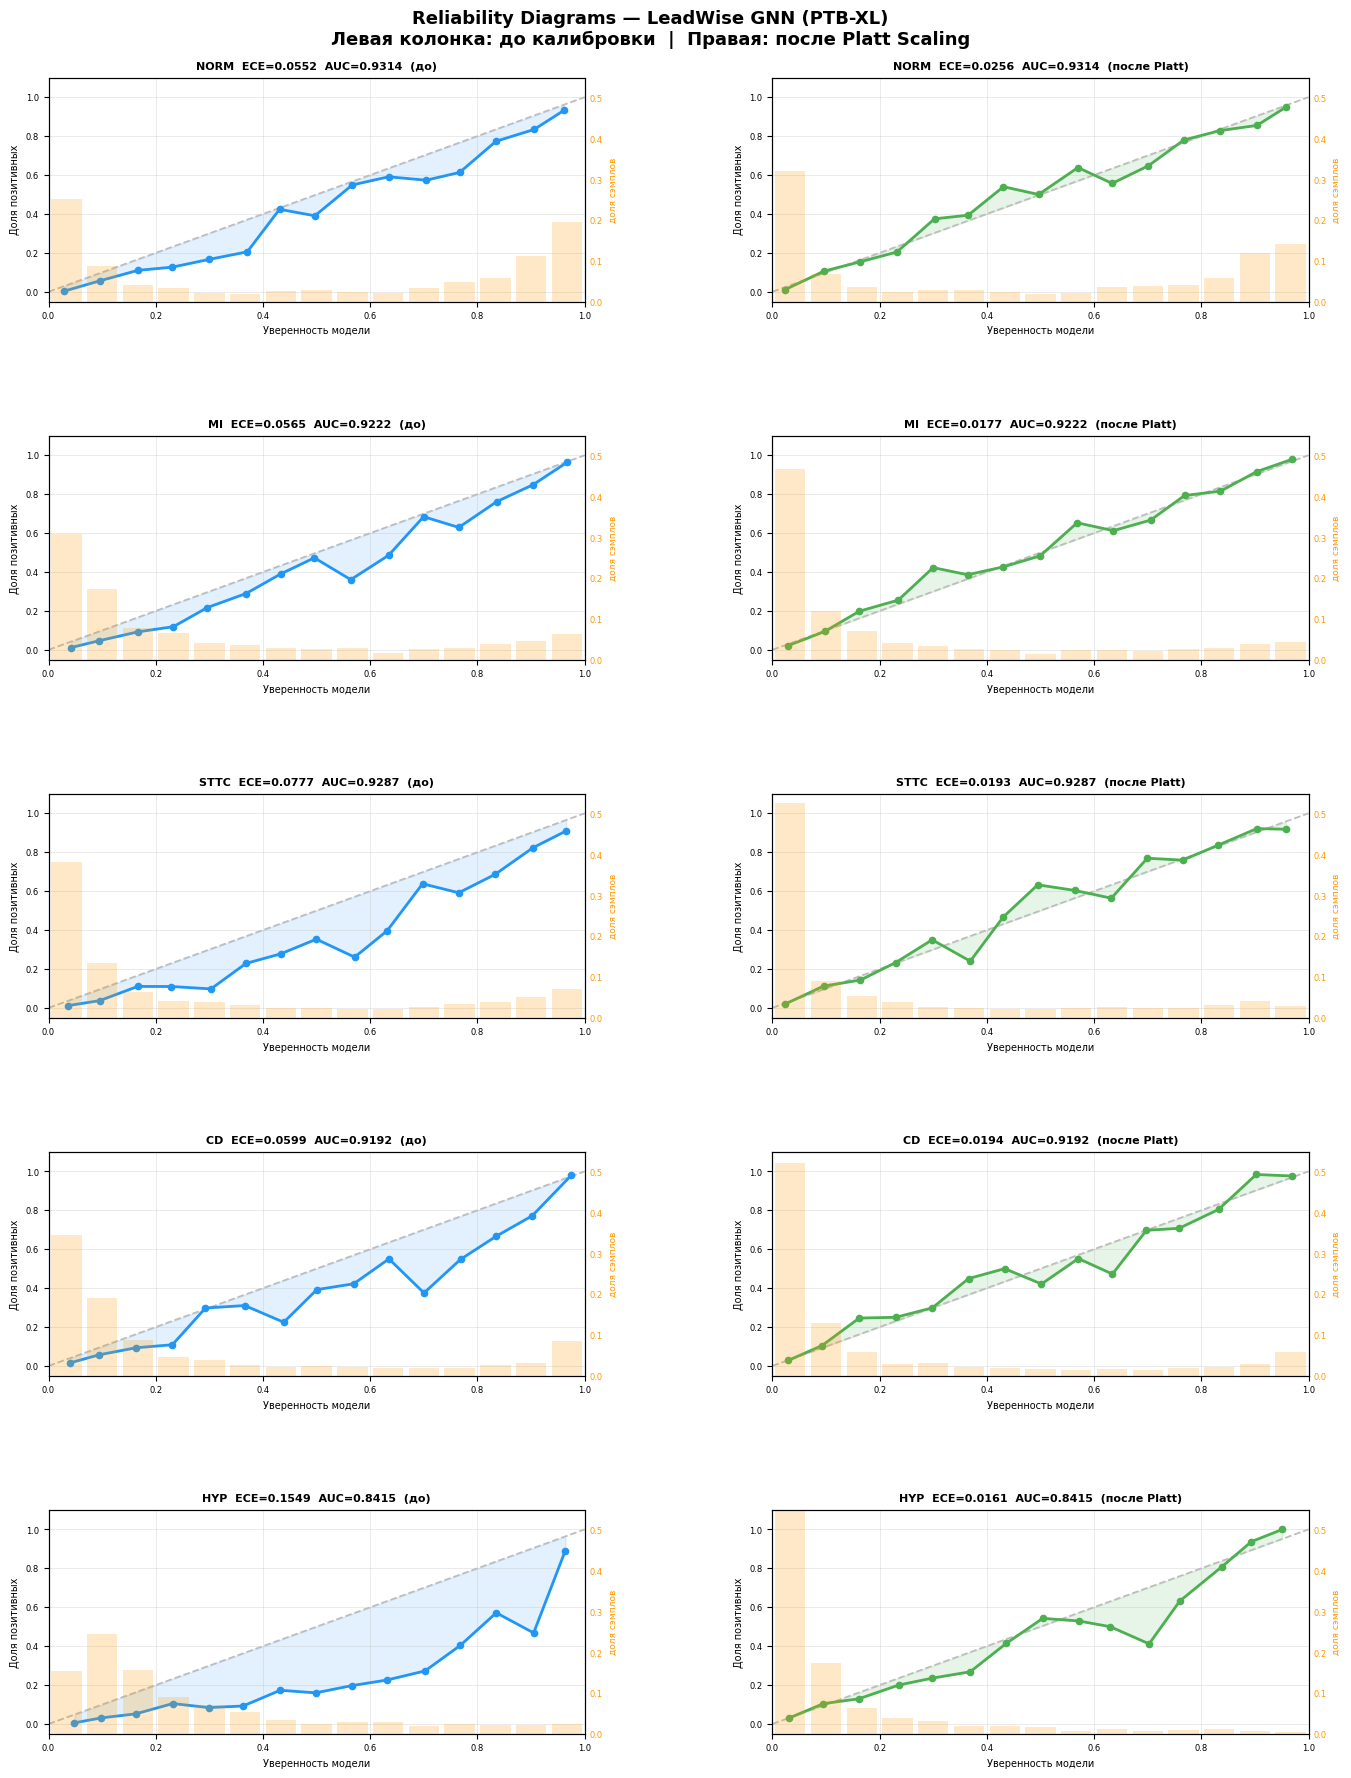


✅ 05_calibration.png → /content/drive/MyDrive/ecg-multigraph-lab/results/05_calibration.png
✅ calibration_params.npz → /content/drive/MyDrive/ecg-multigraph-lab/results/calibration_params.npz

✅ STEP 11 OK — Platt Calibration завершена
   ECE macro : 0.0808 → 0.0196
   Brier     : 0.0995 → 0.0878
   AUROC     : 0.9086 → 0.9086 (должен ≈ совпадать)
   Доступно  : val_probs_cal, test_probs_cal, calibrator


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  STEP 11 — Per-Class Platt Calibration + ECE  (LeadWise GNN)           ║
# ║  ✅ Работает БЕЗ STEP 9 — грузит чекпоинт и делает inference сам        ║
# ║  Требует: STEP 1–8 выполнены (модель определена, данные загружены)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, json, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss
)
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК A — Автопоиск всего необходимого из контекста (STEP 1–8)
# ══════════════════════════════════════════════════════════════════════════════

def _g(names, default=None):
    """Безопасно достаёт первое найденное имя из globals()."""
    for n in names:
        if n in globals():
            return globals()[n]
    return default

def _require(names, hint=""):
    v = _g(names)
    if v is None:
        raise NameError(
            f"❌ Не найдена переменная: {names}\n"
            f"   Убедись что {hint} выполнен."
        )
    return v

# --- Архитектура (STEP 8) ---
MODEL_CLASS = _require(["LeadWiseResNetGNN"],
                       "STEP 8 (определение класса LeadWiseResNetGNN)")

# --- Данные (STEP 4) ---
val_loader_s11  = _require(["val_loader"],  "STEP 4")
test_loader_s11 = _require(["test_loader"], "STEP 4")

# --- Гиперпараметры (STEP 2 / STEP 9) ---
CLASS_NAMES = _g(["CLASS_NAMES", "CLASSNAMES", "class_names"],
                 default=["NORM", "MI", "STTC", "CD", "HYP"])
EMBEDDIM    = _g(["EMBEDDIM", "EMBED_DIM"],   default=128)
HIDDENDIM   = _g(["HIDDENDIM", "HIDDEN_DIM"], default=96)
DROPOUT     = _g(["DROPOUT"],                 default=0.15)
N_CLASSES   = len(CLASS_NAMES)
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- SAVEDIR (STEP 2 или STEP 10) ---
DRIVEROOT_s11 = _g(["DRIVEROOT", "PROJECT_ROOT", "DRIVE_ROOT"],
                   default=Path("/content/drive/MyDrive/ecg-multigraph-lab"))
DRIVEROOT_s11 = Path(DRIVEROOT_s11)
SAVEDIR_s11   = _g(["SAVEDIR"],
                   default=DRIVEROOT_s11 / "results")
SAVEDIR_s11   = Path(SAVEDIR_s11)
SAVEDIR_s11.mkdir(parents=True, exist_ok=True)

# --- Чекпоинт ---
CKPT_CANDIDATES = [
    _g(["CKPTS2"], default=None),
    DRIVEROOT_s11 / "checkpoints" / "gnn_stage2_best.pth",
    DRIVEROOT_s11 / "checkpoints" / "gnn_stage1_best.pth",
    DRIVEROOT_s11 / "checkpoints" / "best.pth",
]
CKPT_PATH_s11 = None
for c in CKPT_CANDIDATES:
    if c is not None and Path(c).exists():
        CKPT_PATH_s11 = Path(c)
        break
if CKPT_PATH_s11 is None:
    # рекурсивный поиск
    found = list(DRIVEROOT_s11.rglob("gnn_stage2_best.pth")) + \
            list(DRIVEROOT_s11.rglob("gnn_stage1_best.pth")) + \
            list(DRIVEROOT_s11.rglob("best.pth"))
    if found:
        CKPT_PATH_s11 = found[0]
if CKPT_PATH_s11 is None:
    raise FileNotFoundError(
        "❌ Чекпоинт не найден!\n"
        f"   Ищем в: {DRIVEROOT_s11}\n"
        "   Убедись что STEP 9 хотя бы раз завершился и сохранил .pth"
    )

print("=" * 65)
print("STEP 11 — Per-Class Platt Calibration + ECE")
print("=" * 65)
print(f"  Device    : {DEVICE}")
print(f"  Classes   : {CLASS_NAMES}")
print(f"  EMBEDDIM  : {EMBEDDIM}  HIDDENDIM: {HIDDENDIM}")
print(f"  Чекпоинт  : {CKPT_PATH_s11}")
print(f"  SAVEDIR   : {SAVEDIR_s11}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК B — Загрузка модели из чекпоинта (если STEP 9 не выполнен)
# ══════════════════════════════════════════════════════════════════════════════

def _load_model_from_ckpt(ckpt_path, device):
    """
    Загружает LeadWiseResNetGNN из .pth файла.
    Поддерживает три формата сохранения:
      - torch.save(model.state_dict(), path)               → dict со слоями
      - torch.save({'model_state_dict': ..., ...}, path)   → обёртка
      - torch.save({'state_dict': ..., ...}, path)         → обёртка v2
    """
    raw = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    if isinstance(raw, dict):
        sd = (raw.get("model_state_dict")
              or raw.get("state_dict")
              or raw.get("model")
              or raw)
    else:
        sd = raw

    mdl = MODEL_CLASS(
        embed_dim   = EMBEDDIM,
        hidden_dim  = HIDDENDIM,
        num_classes = N_CLASSES,
        dropout     = DROPOUT,
    ).to(device)

    missing, unexpected = mdl.load_state_dict(sd, strict=False)
    if missing:
        print(f"  ⚠️  Missing keys  ({len(missing)}): {missing[:3]} ...")
    if unexpected:
        print(f"  ⚠️  Unexpected keys ({len(unexpected)}): {unexpected[:3]} ...")

    mdl.eval()
    return mdl


# Проверяем: если глобальная переменная 'model' есть — берём её,
# иначе загружаем из чекпоинта
_model_s11 = _g(["model"])
if _model_s11 is not None:
    # STEP 9 был выполнен: просто перегружаем лучшие веса
    print("\n✅ Модель найдена в памяти → перезагружаем лучший чекпоинт")
    raw = torch.load(CKPT_PATH_s11, map_location="cpu", weights_only=False)
    sd  = (raw.get("model_state_dict") or raw.get("state_dict")
           or raw.get("model") or raw) if isinstance(raw, dict) else raw
    _model_s11.load_state_dict(sd, strict=False)
    _model_s11 = _model_s11.to(DEVICE)
    _model_s11.eval()
    print("   Веса перезагружены из чекпоинта ✓")
else:
    print("\n⚙️  Модель не в памяти (STEP 9 не запускался) → строим из чекпоинта")
    _model_s11 = _load_model_from_ckpt(CKPT_PATH_s11, DEVICE)
    print("   Архитектура построена, веса загружены ✓")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК C — Inference: val_probs + test_probs
# ══════════════════════════════════════════════════════════════════════════════

def _run_inference(model, loader, device, desc=""):
    model.eval()
    all_probs, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            logits, _ = model(xb.to(device))
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(yb.numpy())
    probs  = np.concatenate(all_probs,  axis=0).astype(np.float32)
    labels = np.concatenate(all_labels, axis=0).astype(np.float32)
    print(f"  {desc}: {probs.shape}  [{time.time()-t0:.1f}s]")
    return probs, labels


# Проверяем: уже есть в памяти (STEP 9 сохранял)?
_val_probs   = _g(["val_probs"])
_val_labels  = _g(["val_labels"])
_test_probs  = _g(["test_probs"])
_test_labels = _g(["test_labels"])

need_inference = (
    _val_probs  is None or _val_labels  is None or
    _test_probs is None or _test_labels is None
)

if need_inference:
    print("\n⚙️  Запускаем inference (STEP 9 не выполнен — вычисляем прямо сейчас):")
    _val_probs,  _val_labels  = _run_inference(
        _model_s11, val_loader_s11,  DEVICE, "VAL ")
    _test_probs, _test_labels = _run_inference(
        _model_s11, test_loader_s11, DEVICE, "TEST")
else:
    print("\n✅ val_probs / test_probs найдены в памяти (STEP 9 выполнен)")
    print(f"   val_probs : {_val_probs.shape}")
    print(f"   test_probs: {_test_probs.shape}")

_val_labels  = _val_labels.astype(int)
_test_labels = _test_labels.astype(int)


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК D — ECE
# ══════════════════════════════════════════════════════════════════════════════

def _ece_binary(y_true, y_prob, n_bins=15):
    bins  = np.linspace(0.0, 1.0, n_bins + 1)
    ece   = 0.0
    n     = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum() == 0:
            continue
        ece += (m.sum() / n) * abs(y_true[m].mean() - y_prob[m].mean())
    return float(ece)


def _ece_multi(y_true, y_prob, n_bins=15):
    r = {cls: _ece_binary(y_true[:, i], y_prob[:, i], n_bins)
         for i, cls in enumerate(CLASS_NAMES)}
    r["macro"] = float(np.mean(list(r.values())))
    return r


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК E — Platt Calibrator (pure numpy + Adam)
# ══════════════════════════════════════════════════════════════════════════════

class PlattCalibrator:
    """
    Per-class Platt Scaling:  p_cal = σ(T · logit(p) + b)
    T, b обучаются на VAL через Adam + NLL (binary cross-entropy).
    """
    EPS = 1e-7

    def __init__(self, n_classes, lr=0.01, max_iter=2000):
        self.n   = n_classes
        self.lr  = lr
        self.mi  = max_iter
        self._lT = np.zeros(n_classes, dtype=np.float64)   # log(T)
        self._b  = np.zeros(n_classes, dtype=np.float64)   # bias

    @property
    def T(self):
        return np.exp(self._lT)

    def _logit(self, p):
        return np.log(np.clip(p, self.EPS, 1-self.EPS) /
                      np.clip(1-p, self.EPS, 1-self.EPS))

    def _sig(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

    def _nll(self, lT, b, p, y):
        pc = self._sig(np.exp(lT) * self._logit(p) + b)
        pc = np.clip(pc, self.EPS, 1-self.EPS)
        return -np.mean(y * np.log(pc) + (1-y) * np.log(1-pc))

    def _grad(self, lT, b, p, y):
        T   = np.exp(lT)
        lp  = self._logit(p)
        err = self._sig(T * lp + b) - y
        return np.mean(err * T * lp), np.mean(err)   # ∂/∂log_T, ∂/∂b

    def fit(self, val_p, val_y):
        b1, b2, ea = 0.9, 0.999, 1e-8
        for i in range(self.n):
            p, y = val_p[:, i].astype(np.float64), val_y[:, i].astype(np.float64)
            lT, b = 0.0, 0.0
            m1 = m2 = v1 = v2 = 0.0
            best_nll, bLT, bB = self._nll(lT, b, p, y), lT, b
            for s in range(1, self.mi + 1):
                g1, g2 = self._grad(lT, b, p, y)
                m1 = b1*m1 + (1-b1)*g1;  v1 = b2*v1 + (1-b2)*g1**2
                m2 = b1*m2 + (1-b1)*g2;  v2 = b2*v2 + (1-b2)*g2**2
                lr = self.lr * (1-b2**s)**0.5 / (1-b1**s)
                lT -= lr * m1 / (v1**0.5 + ea)
                b  -= lr * m2 / (v2**0.5 + ea)
                nll = self._nll(lT, b, p, y)
                if nll < best_nll:
                    best_nll, bLT, bB = nll, lT, b
            self._lT[i], self._b[i] = bLT, bB
        return self

    def predict(self, probs):
        out = np.empty_like(probs, dtype=np.float32)
        for i in range(self.n):
            out[:, i] = self._sig(
                self.T[i] * self._logit(probs[:, i]) + self._b[i]
            )
        return out


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК F — Сводные метрики
# ══════════════════════════════════════════════════════════════════════════════

def _fmax(yt, yp, n=201):
    return max(
        f1_score(yt, (yp >= t).astype(int), average='macro', zero_division=0)
        for t in np.linspace(0, 1, n)
    )

def _metrics(probs, labels):
    try:
        auc = roc_auc_score(labels, probs, average='macro')
    except ValueError:
        auc = float('nan')

    try:
        aupr = average_precision_score(labels, probs, average='macro')
    except ValueError:
        aupr = float('nan')

    try:
        hyp = average_precision_score(labels[:, -1], probs[:, -1])
    except ValueError:
        hyp = float('nan')

    try:
        brier = float(np.mean([
            brier_score_loss(labels[:, i], probs[:, i])
            for i in range(labels.shape[1])
        ]))
    except ValueError:
        brier = float('nan')

    return dict(
        auc   = auc,
        aupr  = aupr,
        hyp   = hyp,
        fmax  = _fmax(labels, probs),
        brier = brier,
        ece   = _ece_multi(labels, probs),
    )


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК G — Обучение + применение калибратора
# ══════════════════════════════════════════════════════════════════════════════

print("\n📊 Метрики ДО калибровки (TEST):")
mb = _metrics(_test_probs, _test_labels)

print("\n🔧 Обучаем Platt Calibrator на VAL ...")
cal = PlattCalibrator(N_CLASSES, lr=0.01, max_iter=2000)
cal.fit(_val_probs, _val_labels)

val_probs_cal  = cal.predict(_val_probs)
test_probs_cal = cal.predict(_test_probs)

print("\n📊 Метрики ПОСЛЕ калибровки (TEST):")
ma = _metrics(test_probs_cal, _test_labels)

# --- Таблица ---
def _d(a, b):
    d = a - b
    return f"{'+'if d>=0 else '−'}{abs(d):.4f}"

print()
print("─" * 66)
print(f"  {'Метрика':22s}  {'До':>10s}  {'После':>10s}  {'Δ':>9s}")
print("─" * 66)
for name, vb, va in [
    ("Macro AUROC",     mb["auc"],   ma["auc"]),
    ("Macro AUPRC",     mb["aupr"],  ma["aupr"]),
    ("HYP AUPRC",       mb["hyp"],   ma["hyp"]),
    ("Fmax",            mb["fmax"],  ma["fmax"]),
    ("J (0.6·AP+0.4·H)",0.6*mb["aupr"]+0.4*mb["hyp"],
                        0.6*ma["aupr"]+0.4*ma["hyp"]),
    ("ECE macro ↓",     mb["ece"]["macro"], ma["ece"]["macro"]),
    ("Brier macro ↓",   mb["brier"], ma["brier"]),
]:
    print(f"  {name:22s}  {vb:10.4f}  {va:10.4f}  {_d(va,vb):>9s}")
print("─" * 66)

print("\n  Per-class ECE (↓ лучше):")
print(f"  {'Class':8s}  {'T':>7s}  {'b':>7s}  {'ECE до':>8s}  {'ECE после':>9s}  {'Δ':>8s}")
print("  " + "─" * 52)
for i, cls in enumerate(CLASS_NAMES):
    vb = mb["ece"][cls]; va = ma["ece"][cls]
    print(f"  {cls:8s}  {cal.T[i]:7.4f}  {cal._b[i]:7.4f}  "
          f"{vb:8.4f}  {va:9.4f}  {_d(va,vb):>8s}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК H — Reliability Diagrams → 05_calibration.png
# ══════════════════════════════════════════════════════════════════════════════

def _rel_data(yt, yp, n_bins=15):
    bins  = np.linspace(0, 1, n_bins+1)
    conf  = np.full(n_bins, np.nan)
    frac  = np.full(n_bins, np.nan)
    cnt   = np.zeros(n_bins)
    for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
        m = (yp >= lo) & (yp < hi)
        if m.sum():
            conf[k] = yp[m].mean()
            frac[k] = yt[m].mean()
        cnt[k] = m.sum()
    return conf, frac, cnt, _ece_binary(yt, yp, n_bins)

C_BEFORE = "#2196F3"
C_AFTER  = "#4CAF50"
C_HIST   = "#FF9800"
C_DIAG   = "#BDBDBD"
N_BINS   = 15

fig = plt.figure(figsize=(14, 18))
fig.suptitle(
    "Reliability Diagrams — LeadWise GNN (PTB-XL)\n"
    "Левая колонка: до калибровки  |  Правая: после Platt Scaling",
    fontsize=13, fontweight="bold", y=0.998
)
gs = gridspec.GridSpec(N_CLASSES, 2,
                       figure=fig, hspace=0.60, wspace=0.35,
                       top=0.96, bottom=0.04, left=0.07, right=0.97)

bin_centers = np.linspace(1/(2*N_BINS), 1-1/(2*N_BINS), N_BINS)

for i, cls in enumerate(CLASS_NAMES):
    yt = _test_labels[:, i]
    for col, (yp, lbl, color) in enumerate([
        (_test_probs[:, i],   "до",    C_BEFORE),
        (test_probs_cal[:, i],"после", C_AFTER),
    ]):
        ax = fig.add_subplot(gs[i, col])
        cf, fr, cnt, ece_v = _rel_data(yt, yp)

        ax2 = ax.twinx()
        ax2.bar(bin_centers, cnt/cnt.sum(), width=1/N_BINS*0.85,
                color=C_HIST, alpha=0.22)
        ax2.set_ylim(0, 0.55)
        ax2.set_ylabel("доля сэмплов", fontsize=6.5, color=C_HIST)
        ax2.tick_params(axis='y', labelcolor=C_HIST, labelsize=6, length=0)

        ax.plot([0, 1], [0, 1], "--", color=C_DIAG, lw=1.3, zorder=2)
        v = ~np.isnan(fr)
        ax.plot(cf[v], fr[v], "o-", color=color, lw=2.0, ms=4.5, zorder=3)
        ax.fill_between(cf[v], cf[v], fr[v], alpha=0.13, color=color)

        auc_i = roc_auc_score(yt, yp)
        ax.set_title(
            f"{cls}  ECE={ece_v:.4f}  AUC={auc_i:.4f}"
            f"  ({'до' if col==0 else 'после Platt'})",
            fontsize=8, fontweight="bold"
        )
        ax.set_xlim(0,1); ax.set_ylim(-0.05, 1.1)
        ax.set_xlabel("Уверенность модели", fontsize=7)
        ax.set_ylabel("Доля позитивных", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.3, lw=0.6)

save_fig = SAVEDIR_s11 / "05_calibration.png"
fig.savefig(save_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ 05_calibration.png → {save_fig}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК I — Сохранение параметров + экспорт в globals
# ══════════════════════════════════════════════════════════════════════════════

cal_npz = SAVEDIR_s11 / "calibration_params.npz"
np.savez(
    cal_npz,
    T           = cal.T,
    b           = cal._b,
    log_T       = cal._lT,
    class_names = np.array(CLASS_NAMES),
)
print(f"✅ calibration_params.npz → {cal_npz}")

globals()["val_probs_cal"]  = val_probs_cal
globals()["test_probs_cal"] = test_probs_cal
globals()["calibrator"]     = cal

print()
print("=" * 65)
print("✅ STEP 11 OK — Platt Calibration завершена")
print(f"   ECE macro : {mb['ece']['macro']:.4f} → {ma['ece']['macro']:.4f}")
print(f"   Brier     : {mb['brier']:.4f} → {ma['brier']:.4f}")
print(f"   AUROC     : {mb['auc']:.4f} → {ma['auc']:.4f} (должен ≈ совпадать)")
print(f"   Доступно  : val_probs_cal, test_probs_cal, calibrator")
print("=" * 65)


STEP 11 — Per-Class Platt Calibration + ECE
  Device    : cuda
  Classes   : ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  EMBEDDIM  : 128  HIDDENDIM: 96
  Чекпоинт  : /content/drive/MyDrive/ecg-multigraph-lab/checkpoints/gnn_stage2_best.pth
  SAVEDIR   : /content/drive/MyDrive/ecg-multigraph-lab/results

⚙️  Модель не в памяти (STEP 9 не запускался) → строим из чекпоинта
   Архитектура построена, веса загружены ✓

⚙️  Запускаем inference (STEP 9 не выполнен — вычисляем прямо сейчас):
  VAL : (2183, 5)  [5.4s]
  TEST: (2198, 5)  [5.6s]

📊 Метрики ДО калибровки (TEST):

🔧 Обучаем Platt Calibrator на VAL ...

📊 Метрики ПОСЛЕ калибровки (TEST):

──────────────────────────────────────────────────────────────────
  Метрика                         До       После          Δ
──────────────────────────────────────────────────────────────────
  Macro AUROC                 0.9086      0.9086    +0.0000
  Macro AUPRC                 0.7803      0.7803    +0.0000
  HYP AUPRC                   0.5455      0

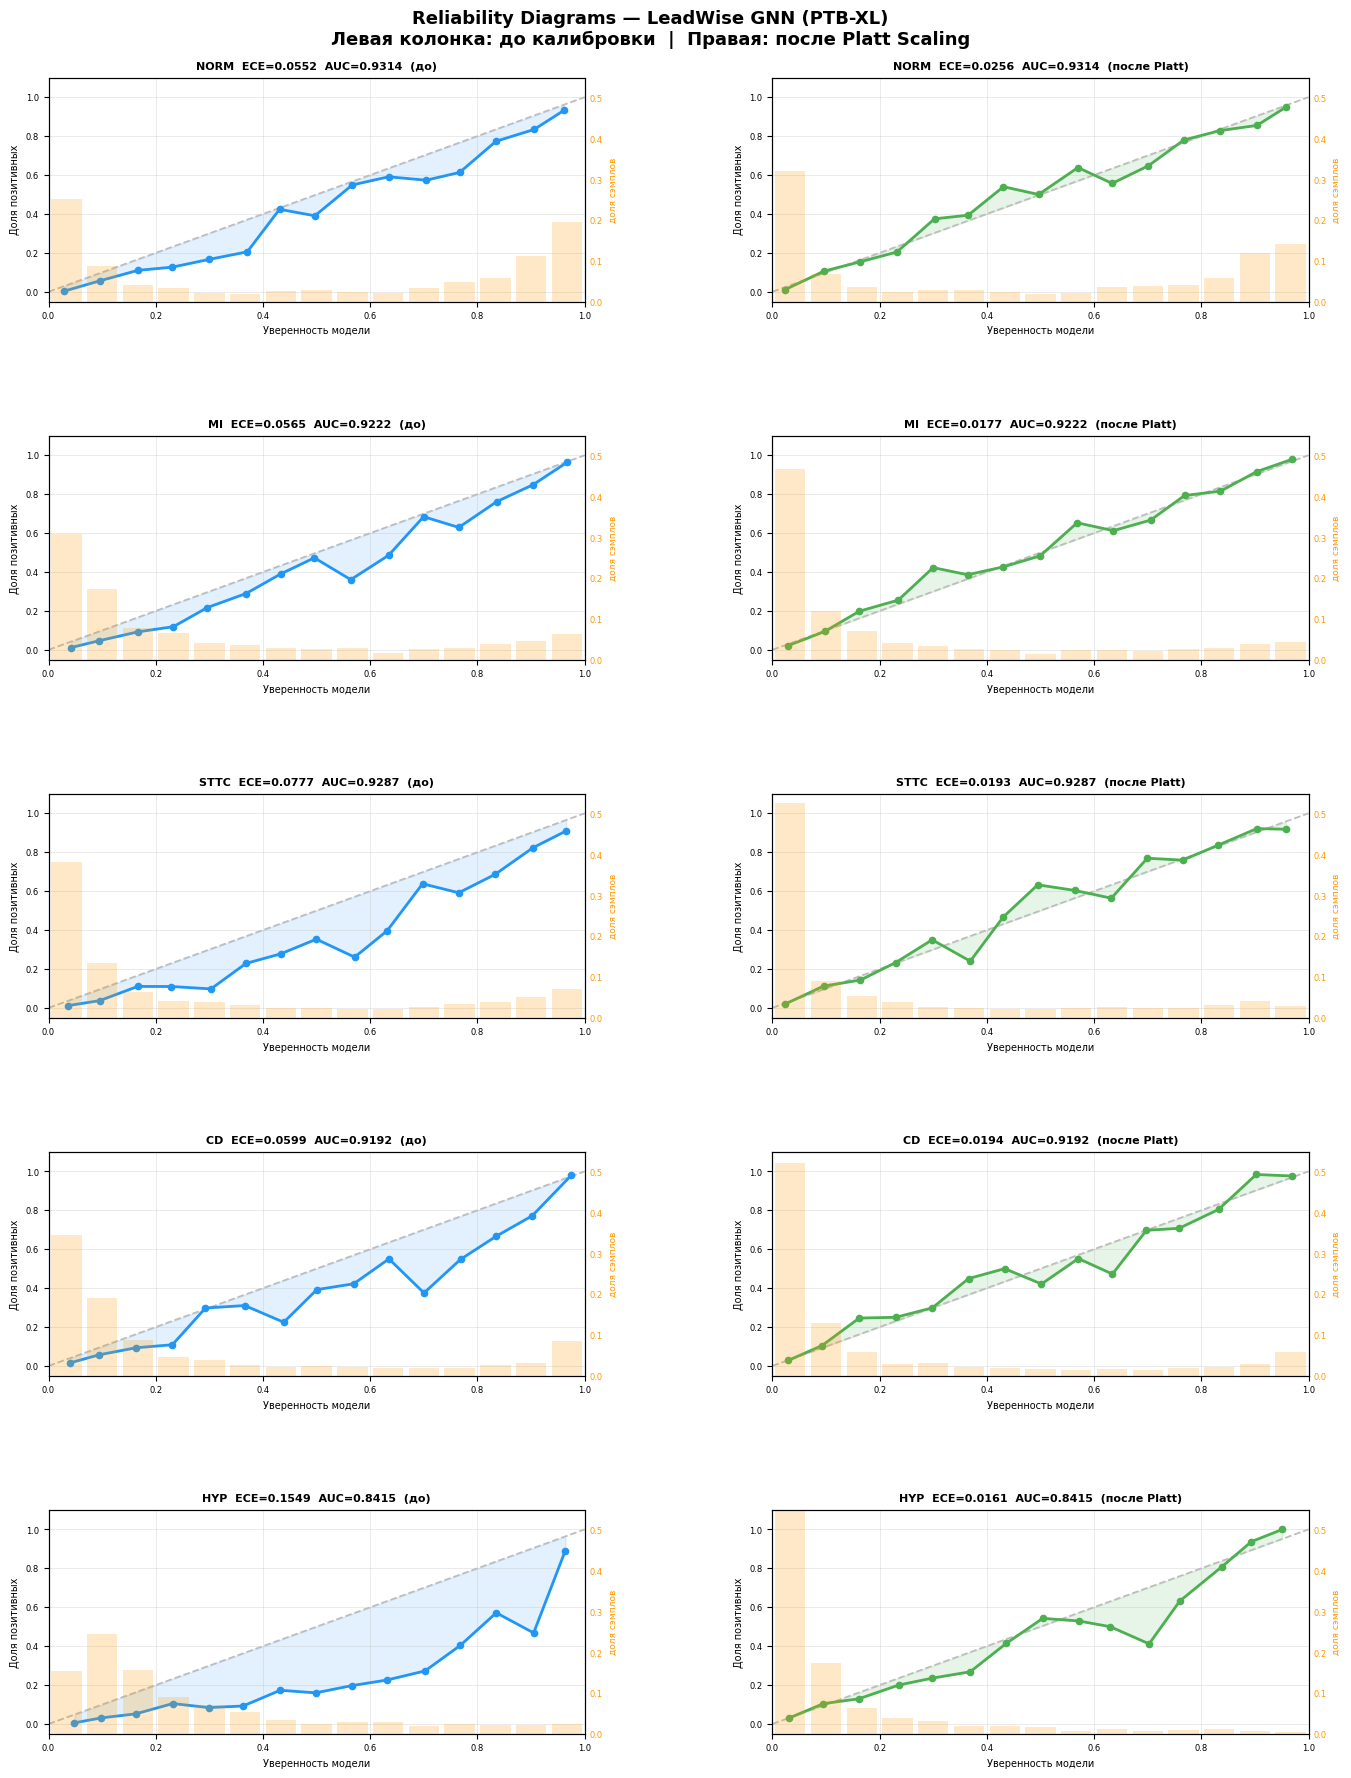


✅ 05_calibration.png → /content/drive/MyDrive/ecg-multigraph-lab/results/05_calibration.png
✅ calibration_params.npz → /content/drive/MyDrive/ecg-multigraph-lab/results/calibration_params.npz

✅ STEP 11 OK — Platt Calibration завершена
   ECE macro : 0.0808 → 0.0196
   Brier     : 0.0995 → 0.0878
   AUROC     : 0.9086 → 0.9086 (должен ≈ совпадать)
   Доступно  : val_probs_cal, test_probs_cal, calibrator
                         TEST — leadwise_gnn_model  [ДО калибровки]   

📊 Core Metrics (Official PTB-XL)
   Macro AUROC:  0.9086 (5/5 classes)
   Micro AUROC:  0.9233
   Macro AUPRC:  0.7803
   Fmax:         0.7140 (optimal threshold: 0.570)
   F1 Macro:     0.7226 (@ per-class opt. threshold)
   F1 Micro:     0.7622 (@ per-class opt. threshold)

🏥 Medical Metrics (@ per-class opt. threshold)
   Sensitivity (Recall): 0.7633
   Specificity:          0.8880

📋 Per-Class Metrics
Class        AUROC   AUPRC      F1   Sens.   Spec.  Opt.Thr  Support 
-----------------------------------------

In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  STEP 11 — Per-Class Platt Calibration + ECE  (LeadWise GNN)           ║
# ║  ✅ Работает БЕЗ STEP 9 — грузит чекпоинт и делает inference сам        ║
# ║  Требует: STEP 1–8 выполнены (модель определена, данные загружены)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, json, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss
)
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК A — Автопоиск всего необходимого из контекста (STEP 1–8)
# ══════════════════════════════════════════════════════════════════════════════

def _g(names, default=None):
    """Безопасно достаёт первое найденное имя из globals()."""
    for n in names:
        if n in globals():
            return globals()[n]
    return default

def _require(names, hint=""):
    v = _g(names)
    if v is None:
        raise NameError(
            f"❌ Не найдена переменная: {names}\n"
            f"   Убедись что {hint} выполнен."
        )
    return v

# --- Архитектура (STEP 8) ---
MODEL_CLASS = _require(["LeadWiseResNetGNN"],
                       "STEP 8 (определение класса LeadWiseResNetGNN)")

# --- Данные (STEP 4) ---
val_loader_s11  = _require(["val_loader"],  "STEP 4")
test_loader_s11 = _require(["test_loader"], "STEP 4")

# --- Гиперпараметры (STEP 2 / STEP 9) ---
CLASS_NAMES = _g(["CLASS_NAMES", "CLASSNAMES", "class_names"],
                 default=["NORM", "MI", "STTC", "CD", "HYP"])
EMBEDDIM    = _g(["EMBEDDIM", "EMBED_DIM"],   default=128)
HIDDENDIM   = _g(["HIDDENDIM", "HIDDEN_DIM"], default=96)
DROPOUT     = _g(["DROPOUT"],                 default=0.15)
N_CLASSES   = len(CLASS_NAMES)
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- SAVEDIR (STEP 2 или STEP 10) ---
DRIVEROOT_s11 = _g(["DRIVEROOT", "PROJECT_ROOT", "DRIVE_ROOT"],
                   default=Path("/content/drive/MyDrive/ecg-multigraph-lab"))
DRIVEROOT_s11 = Path(DRIVEROOT_s11)
SAVEDIR_s11   = _g(["SAVEDIR"],
                   default=DRIVEROOT_s11 / "results")
SAVEDIR_s11   = Path(SAVEDIR_s11)
SAVEDIR_s11.mkdir(parents=True, exist_ok=True)

# --- Чекпоинт ---
CKPT_CANDIDATES = [
    _g(["CKPTS2"], default=None),
    DRIVEROOT_s11 / "checkpoints" / "gnn_stage2_best.pth",
    DRIVEROOT_s11 / "checkpoints" / "gnn_stage1_best.pth",
    DRIVEROOT_s11 / "checkpoints" / "best.pth",
]
CKPT_PATH_s11 = None
for c in CKPT_CANDIDATES:
    if c is not None and Path(c).exists():
        CKPT_PATH_s11 = Path(c)
        break
if CKPT_PATH_s11 is None:
    # рекурсивный поиск
    found = list(DRIVEROOT_s11.rglob("gnn_stage2_best.pth")) + \
            list(DRIVEROOT_s11.rglob("gnn_stage1_best.pth")) + \
            list(DRIVEROOT_s11.rglob("best.pth"))
    if found:
        CKPT_PATH_s11 = found[0]
if CKPT_PATH_s11 is None:
    raise FileNotFoundError(
        "❌ Чекпоинт не найден!\n"
        f"   Ищем в: {DRIVEROOT_s11}\n"
        "   Убедись что STEP 9 хотя бы раз завершился и сохранил .pth"
    )

print("=" * 65)
print("STEP 11 — Per-Class Platt Calibration + ECE")
print("=" * 65)
print(f"  Device    : {DEVICE}")
print(f"  Classes   : {CLASS_NAMES}")
print(f"  EMBEDDIM  : {EMBEDDIM}  HIDDENDIM: {HIDDENDIM}")
print(f"  Чекпоинт  : {CKPT_PATH_s11}")
print(f"  SAVEDIR   : {SAVEDIR_s11}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК B — Загрузка модели из чекпоинта (если STEP 9 не выполнен)
# ══════════════════════════════════════════════════════════════════════════════

def _load_model_from_ckpt(ckpt_path, device):
    """
    Загружает LeadWiseResNetGNN из .pth файла.
    Поддерживает три формата сохранения:
      - torch.save(model.state_dict(), path)               → dict со слоями
      - torch.save({'model_state_dict': ..., ...}, path)   → обёртка
      - torch.save({'state_dict': ..., ...}, path)         → обёртка v2
    """
    raw = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    if isinstance(raw, dict):
        sd = (raw.get("model_state_dict")
              or raw.get("state_dict")
              or raw.get("model")
              or raw)
    else:
        sd = raw

    mdl = MODEL_CLASS(
        embed_dim   = EMBEDDIM,
        hidden_dim  = HIDDENDIM,
        num_classes = N_CLASSES,
        dropout     = DROPOUT,
    ).to(device)

    missing, unexpected = mdl.load_state_dict(sd, strict=False)
    if missing:
        print(f"  ⚠️  Missing keys  ({len(missing)}): {missing[:3]} ...")
    if unexpected:
        print(f"  ⚠️  Unexpected keys ({len(unexpected)}): {unexpected[:3]} ...")

    mdl.eval()
    return mdl


# Проверяем: если глобальная переменная 'model' есть — берём её,
# иначе загружаем из чекпоинта
_model_s11 = _g(["model"])
if _model_s11 is not None:
    # STEP 9 был выполнен: просто перегружаем лучшие веса
    print("\n✅ Модель найдена в памяти → перезагружаем лучший чекпоинт")
    raw = torch.load(CKPT_PATH_s11, map_location="cpu", weights_only=False)
    sd  = (raw.get("model_state_dict") or raw.get("state_dict")
           or raw.get("model") or raw) if isinstance(raw, dict) else raw
    _model_s11.load_state_dict(sd, strict=False)
    _model_s11 = _model_s11.to(DEVICE)
    _model_s11.eval()
    print("   Веса перезагружены из чекпоинта ✓")
else:
    print("\n⚙️  Модель не в памяти (STEP 9 не запускался) → строим из чекпоинта")
    _model_s11 = _load_model_from_ckpt(CKPT_PATH_s11, DEVICE)
    print("   Архитектура построена, веса загружены ✓")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК C — Inference: val_probs + test_probs
# ══════════════════════════════════════════════════════════════════════════════

def _run_inference(model, loader, device, desc=""):
    model.eval()
    all_probs, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            logits, _ = model(xb.to(device))
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(yb.numpy())
    probs  = np.concatenate(all_probs,  axis=0).astype(np.float32)
    labels = np.concatenate(all_labels, axis=0).astype(np.float32)
    print(f"  {desc}: {probs.shape}  [{time.time()-t0:.1f}s]")
    return probs, labels


# Проверяем: уже есть в памяти (STEP 9 сохранял)?
_val_probs   = _g(["val_probs"])
_val_labels  = _g(["val_labels"])
_test_probs  = _g(["test_probs"])
_test_labels = _g(["test_labels"])

need_inference = (
    _val_probs  is None or _val_labels  is None or
    _test_probs is None or _test_labels is None
)

if need_inference:
    print("\n⚙️  Запускаем inference (STEP 9 не выполнен — вычисляем прямо сейчас):")
    _val_probs,  _val_labels  = _run_inference(
        _model_s11, val_loader_s11,  DEVICE, "VAL ")
    _test_probs, _test_labels = _run_inference(
        _model_s11, test_loader_s11, DEVICE, "TEST")
else:
    print("\n✅ val_probs / test_probs найдены в памяти (STEP 9 выполнен)")
    print(f"   val_probs : {_val_probs.shape}")
    print(f"   test_probs: {_test_probs.shape}")

_val_labels  = _val_labels.astype(int)
_test_labels = _test_labels.astype(int)


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК D — ECE
# ══════════════════════════════════════════════════════════════════════════════

def _ece_binary(y_true, y_prob, n_bins=15):
    bins  = np.linspace(0.0, 1.0, n_bins + 1)
    ece   = 0.0
    n     = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum() == 0:
            continue
        ece += (m.sum() / n) * abs(y_true[m].mean() - y_prob[m].mean())
    return float(ece)


def _ece_multi(y_true, y_prob, n_bins=15):
    r = {cls: _ece_binary(y_true[:, i], y_prob[:, i], n_bins)
         for i, cls in enumerate(CLASS_NAMES)}
    r["macro"] = float(np.mean(list(r.values())))
    return r


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК E — Platt Calibrator (pure numpy + Adam)
# ══════════════════════════════════════════════════════════════════════════════

class PlattCalibrator:
    """
    Per-class Platt Scaling:  p_cal = σ(T · logit(p) + b)
    T, b обучаются на VAL через Adam + NLL (binary cross-entropy).
    """
    EPS = 1e-7

    def __init__(self, n_classes, lr=0.01, max_iter=2000):
        self.n   = n_classes
        self.lr  = lr
        self.mi  = max_iter
        self._lT = np.zeros(n_classes, dtype=np.float64)   # log(T)
        self._b  = np.zeros(n_classes, dtype=np.float64)   # bias

    @property
    def T(self):
        return np.exp(self._lT)

    def _logit(self, p):
        return np.log(np.clip(p, self.EPS, 1-self.EPS) /
                      np.clip(1-p, self.EPS, 1-self.EPS))

    def _sig(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

    def _nll(self, lT, b, p, y):
        pc = self._sig(np.exp(lT) * self._logit(p) + b)
        pc = np.clip(pc, self.EPS, 1-self.EPS)
        return -np.mean(y * np.log(pc) + (1-y) * np.log(1-pc))

    def _grad(self, lT, b, p, y):
        T   = np.exp(lT)
        lp  = self._logit(p)
        err = self._sig(T * lp + b) - y
        return np.mean(err * T * lp), np.mean(err)   # ∂/∂log_T, ∂/∂b

    def fit(self, val_p, val_y):
        b1, b2, ea = 0.9, 0.999, 1e-8
        for i in range(self.n):
            p, y = val_p[:, i].astype(np.float64), val_y[:, i].astype(np.float64)
            lT, b = 0.0, 0.0
            m1 = m2 = v1 = v2 = 0.0
            best_nll, bLT, bB = self._nll(lT, b, p, y), lT, b
            for s in range(1, self.mi + 1):
                g1, g2 = self._grad(lT, b, p, y)
                m1 = b1*m1 + (1-b1)*g1;  v1 = b2*v1 + (1-b2)*g1**2
                m2 = b1*m2 + (1-b1)*g2;  v2 = b2*v2 + (1-b2)*g2**2
                lr = self.lr * (1-b2**s)**0.5 / (1-b1**s)
                lT -= lr * m1 / (v1**0.5 + ea)
                b  -= lr * m2 / (v2**0.5 + ea)
                nll = self._nll(lT, b, p, y)
                if nll < best_nll:
                    best_nll, bLT, bB = nll, lT, b
            self._lT[i], self._b[i] = bLT, bB
        return self

    def predict(self, probs):
        out = np.empty_like(probs, dtype=np.float32)
        for i in range(self.n):
            out[:, i] = self._sig(
                self.T[i] * self._logit(probs[:, i]) + self._b[i]
            )
        return out


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК F — Сводные метрики
# ══════════════════════════════════════════════════════════════════════════════

def _fmax(yt, yp, n=201):
    return max(
        f1_score(yt, (yp >= t).astype(int), average='macro', zero_division=0)
        for t in np.linspace(0, 1, n)
    )

def _metrics(probs, labels):
    try:
        auc = roc_auc_score(labels, probs, average='macro')
    except ValueError:
        auc = float('nan')

    try:
        aupr = average_precision_score(labels, probs, average='macro')
    except ValueError:
        aupr = float('nan')

    try:
        hyp = average_precision_score(labels[:, -1], probs[:, -1])
    except ValueError:
        hyp = float('nan')

    try:
        brier = float(np.mean([
            brier_score_loss(labels[:, i], probs[:, i])
            for i in range(labels.shape[1])
        ]))
    except ValueError:
        brier = float('nan')

    return dict(
        auc   = auc,
        aupr  = aupr,
        hyp   = hyp,
        fmax  = _fmax(labels, probs),
        brier = brier,
        ece   = _ece_multi(labels, probs),
    )


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК G — Обучение + применение калибратора
# ══════════════════════════════════════════════════════════════════════════════

print("\n📊 Метрики ДО калибровки (TEST):")
mb = _metrics(_test_probs, _test_labels)

print("\n🔧 Обучаем Platt Calibrator на VAL ...")
cal = PlattCalibrator(N_CLASSES, lr=0.01, max_iter=2000)
cal.fit(_val_probs, _val_labels)

val_probs_cal  = cal.predict(_val_probs)
test_probs_cal = cal.predict(_test_probs)

print("\n📊 Метрики ПОСЛЕ калибровки (TEST):")
ma = _metrics(test_probs_cal, _test_labels)

# --- Таблица ---
def _d(a, b):
    d = a - b
    return f"{'+'if d>=0 else '−'}{abs(d):.4f}"

print()
print("─" * 66)
print(f"  {'Метрика':22s}  {'До':>10s}  {'После':>10s}  {'Δ':>9s}")
print("─" * 66)
for name, vb, va in [
    ("Macro AUROC",     mb["auc"],   ma["auc"]),
    ("Macro AUPRC",     mb["aupr"],  ma["aupr"]),
    ("HYP AUPRC",       mb["hyp"],   ma["hyp"]),
    ("Fmax",            mb["fmax"],  ma["fmax"]),
    ("J (0.6·AP+0.4·H)",0.6*mb["aupr"]+0.4*mb["hyp"],
                        0.6*ma["aupr"]+0.4*ma["hyp"]),
    ("ECE macro ↓",     mb["ece"]["macro"], ma["ece"]["macro"]),
    ("Brier macro ↓",   mb["brier"], ma["brier"]),
]:
    print(f"  {name:22s}  {vb:10.4f}  {va:10.4f}  {_d(va,vb):>9s}")
print("─" * 66)

print("\n  Per-class ECE (↓ лучше):")
print(f"  {'Class':8s}  {'T':>7s}  {'b':>7s}  {'ECE до':>8s}  {'ECE после':>9s}  {'Δ':>8s}")
print("  " + "─" * 52)
for i, cls in enumerate(CLASS_NAMES):
    vb = mb["ece"][cls]; va = ma["ece"][cls]
    print(f"  {cls:8s}  {cal.T[i]:7.4f}  {cal._b[i]:7.4f}  "
          f"{vb:8.4f}  {va:9.4f}  {_d(va,vb):>8s}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК H — Reliability Diagrams → 05_calibration.png
# ══════════════════════════════════════════════════════════════════════════════

def _rel_data(yt, yp, n_bins=15):
    bins  = np.linspace(0, 1, n_bins+1)
    conf  = np.full(n_bins, np.nan)
    frac  = np.full(n_bins, np.nan)
    cnt   = np.zeros(n_bins)
    for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
        m = (yp >= lo) & (yp < hi)
        if m.sum():
            conf[k] = yp[m].mean()
            frac[k] = yt[m].mean()
        cnt[k] = m.sum()
    return conf, frac, cnt, _ece_binary(yt, yp, n_bins)

C_BEFORE = "#2196F3"
C_AFTER  = "#4CAF50"
C_HIST   = "#FF9800"
C_DIAG   = "#BDBDBD"
N_BINS   = 15

fig = plt.figure(figsize=(14, 18))
fig.suptitle(
    "Reliability Diagrams — LeadWise GNN (PTB-XL)\n"
    "Левая колонка: до калибровки  |  Правая: после Platt Scaling",
    fontsize=13, fontweight="bold", y=0.998
)
gs = gridspec.GridSpec(N_CLASSES, 2,
                       figure=fig, hspace=0.60, wspace=0.35,
                       top=0.96, bottom=0.04, left=0.07, right=0.97)

bin_centers = np.linspace(1/(2*N_BINS), 1-1/(2*N_BINS), N_BINS)

for i, cls in enumerate(CLASS_NAMES):
    yt = _test_labels[:, i]
    for col, (yp, lbl, color) in enumerate([
        (_test_probs[:, i],   "до",    C_BEFORE),
        (test_probs_cal[:, i],"после", C_AFTER),
    ]):
        ax = fig.add_subplot(gs[i, col])
        cf, fr, cnt, ece_v = _rel_data(yt, yp)

        ax2 = ax.twinx()
        ax2.bar(bin_centers, cnt/cnt.sum(), width=1/N_BINS*0.85,
                color=C_HIST, alpha=0.22)
        ax2.set_ylim(0, 0.55)
        ax2.set_ylabel("доля сэмплов", fontsize=6.5, color=C_HIST)
        ax2.tick_params(axis='y', labelcolor=C_HIST, labelsize=6, length=0)

        ax.plot([0, 1], [0, 1], "--", color=C_DIAG, lw=1.3, zorder=2)
        v = ~np.isnan(fr)
        ax.plot(cf[v], fr[v], "o-", color=color, lw=2.0, ms=4.5, zorder=3)
        ax.fill_between(cf[v], cf[v], fr[v], alpha=0.13, color=color)

        auc_i = roc_auc_score(yt, yp)
        ax.set_title(
            f"{cls}  ECE={ece_v:.4f}  AUC={auc_i:.4f}"
            f"  ({'до' if col==0 else 'после Platt'})",
            fontsize=8, fontweight="bold"
        )
        ax.set_xlim(0,1); ax.set_ylim(-0.05, 1.1)
        ax.set_xlabel("Уверенность модели", fontsize=7)
        ax.set_ylabel("Доля позитивных", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.3, lw=0.6)

save_fig = SAVEDIR_s11 / "05_calibration.png"
fig.savefig(save_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ 05_calibration.png → {save_fig}")


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК I — Сохранение параметров + экспорт в globals
# ══════════════════════════════════════════════════════════════════════════════

cal_npz = SAVEDIR_s11 / "calibration_params.npz"
np.savez(
    cal_npz,
    T           = cal.T,
    b           = cal._b,
    log_T       = cal._lT,
    class_names = np.array(CLASS_NAMES),
)
print(f"✅ calibration_params.npz → {cal_npz}")

globals()["val_probs_cal"]  = val_probs_cal
globals()["test_probs_cal"] = test_probs_cal
globals()["calibrator"]     = cal

print()
print("=" * 65)
print("✅ STEP 11 OK — Platt Calibration завершена")
print(f"   ECE macro : {mb['ece']['macro']:.4f} → {ma['ece']['macro']:.4f}")
print(f"   Brier     : {mb['brier']:.4f} → {ma['brier']:.4f}")
print(f"   AUROC     : {mb['auc']:.4f} → {ma['auc']:.4f} (должен ≈ совпадать)")
print(f"   Доступно  : val_probs_cal, test_probs_cal, calibrator")
print("=" * 65)


# ══════════════════════════════════════════════════════════════════════════════
# БЛОК J — Full TEST Report: ДО и ПОСЛЕ калибровки
# ══════════════════════════════════════════════════════════════════════════════

def _opt_thresh_perclass(y_true, y_prob, n=201):
    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.0, 1.0, n):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_f1, best_t

def _fmax_thresh(yt, yp, n=201):
    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.0, 1.0, n):
        f1 = f1_score(yt, (yp >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_f1, best_t

def _perclass_opt_thresholds(y_true, y_prob, n=201):
    f1_list, t_list = [], []
    for i in range(y_true.shape[1]):
        f1_i, thr_i = _opt_thresh_perclass(y_true[:, i], y_prob[:, i], n=n)
        f1_list.append(f1_i)
        t_list.append(thr_i)
    return np.array(f1_list, dtype=np.float32), np.array(t_list, dtype=np.float32)

def _sens_spec_from_pred(y_true, y_pred):
    s_list, p_list = [], []
    for i in range(y_true.shape[1]):
        yt = y_true[:, i]; yp = y_pred[:, i]
        tp = ((yp==1)&(yt==1)).sum(); fn = ((yp==0)&(yt==1)).sum()
        fp = ((yp==1)&(yt==0)).sum(); tn = ((yp==0)&(yt==0)).sum()
        s_list.append(tp/(tp+fn+1e-9))
        p_list.append(tn/(tn+fp+1e-9))
    return float(np.mean(s_list)), float(np.mean(p_list))

def print_test_report(probs, labels, class_names, label=""):
    W = 70
    n_cls = len(class_names)

    macro_auc  = roc_auc_score(labels, probs, average='macro')
    micro_auc  = roc_auc_score(labels, probs, average='micro')
    macro_aupr = average_precision_score(labels, probs, average='macro')
    fmax_val, fmax_t = _fmax_thresh(labels, probs)
    f1_opt, thr_opt = _perclass_opt_thresholds(labels, probs)
    pred_opt = (probs >= thr_opt).astype(int)
    f1_macro = f1_score(labels, pred_opt, average='macro', zero_division=0)
    f1_micro = f1_score(labels, pred_opt, average='micro', zero_division=0)
    sens, spec = _sens_spec_from_pred(labels, pred_opt)

    print("=" * W)
    print(f"                      TEST — leadwise_gnn_model  {label}".center(W))
    print("=" * W)
    print()
    print("📊 Core Metrics (Official PTB-XL)")
    print(f"   Macro AUROC:  {macro_auc:.4f} ({n_cls}/{n_cls} classes)")
    print(f"   Micro AUROC:  {micro_auc:.4f}")
    print(f"   Macro AUPRC:  {macro_aupr:.4f}")
    print(f"   Fmax:         {fmax_val:.4f} (optimal threshold: {fmax_t:.3f})")
    print(f"   F1 Macro:     {f1_macro:.4f} (@ per-class opt. threshold)")
    print(f"   F1 Micro:     {f1_micro:.4f} (@ per-class opt. threshold)")
    print()
    print("🏥 Medical Metrics (@ per-class opt. threshold)")
    print(f"   Sensitivity (Recall): {sens:.4f}")
    print(f"   Specificity:          {spec:.4f}")
    print()
    print("📋 Per-Class Metrics")
    print(f"{'Class':<10} {'AUROC':>7} {'AUPRC':>7} {'F1':>7} "
          f"{'Sens.':>7} {'Spec.':>7} {'Opt.Thr':>8} {'Support':>8} ")
    print("-" * W)
    for i, cls in enumerate(class_names):
        yt = labels[:, i]; yp = probs[:, i]
        auc_i  = roc_auc_score(yt, yp)
        aupr_i = average_precision_score(yt, yp)
        f1_i = float(f1_opt[i])
        thr_i = float(thr_opt[i])
        pred_i = pred_opt[:, i]
        tp = ((pred_i==1)&(yt==1)).sum(); fn = ((pred_i==0)&(yt==1)).sum()
        fp = ((pred_i==1)&(yt==0)).sum(); tn = ((pred_i==0)&(yt==0)).sum()
        sens_i = tp/(tp+fn+1e-9); spec_i = tn/(tn+fp+1e-9)
        sup_i  = int(yt.sum())
        print(f"{cls:<10} {auc_i:>7.4f} {aupr_i:>7.4f} {f1_i:>7.4f} "
              f"{sens_i:>7.4f} {spec_i:>7.4f} {thr_i:>8.3f} {sup_i:>8d}   ")
    print("=" * W)


# ── ДО калибровки ─────────────────────────────────────────────────────────────
print_test_report(_test_probs,  _test_labels, CLASS_NAMES, label="[ДО калибровки]")

print()

# ── ПОСЛЕ калибровки ──────────────────────────────────────────────────────────
print_test_report(test_probs_cal, _test_labels, CLASS_NAMES, label="[ПОСЛЕ Platt Calibration]")
